# Bandit plotting
The purpose of this notebook is to plot the preliminary results on the simple single-bandit task.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd


In [2]:
# Move up to main repo directory
import os
os.chdir("../..") # ONLY RUN THIS ONCE

In [3]:
## Load CSV file from file path string

def load_csv(file_path):
    """Load a CSV file and return a pandas DataFrame."""
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded CSV file: {file_path}")
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

### CSV Conversion (OLD)

In [4]:
## Create separate DataFrames for regret, cum_reward, total_reward, and percent_optimal

def process_csv_data(df):
    """Process the CSV data into separate DataFrames for regret, cumulative reward, total reward, and percent optimal.
    Keeps the subfolder name as a column in each DataFrame."""
    step_regret_cols = [col for col in df.columns if 'step_regret' in col]
    step_reward_cols = [col for col in df.columns if 'step_reward' in col]
    cum_regret_cols = [col for col in df.columns if 'cum_regret' in col]
    cum_reward_cols = [col for col in df.columns if 'cum_reward' in col]
    optimal_actions_cols = [col for col in df.columns if 'reward_optimal_actions']
    sem_opt_actions_cols = [col for col in df.columns if 'sem_optimal_actions' in col]

    # Ensure subfolder column is included
    subfolder_col = ['subfolder'] if 'subfolder' in df.columns else []

    step_regret_df = df[subfolder_col + step_regret_cols]
    step_reward_df = df[subfolder_col + step_reward_cols]
    cum_regret_df = df[subfolder_col + cum_regret_cols]
    cum_reward_df = df[subfolder_col + cum_reward_cols]
    percent_optimal_df = df[subfolder_col + percent_optimal_cols]

    return {
        'step_regret': step_regret_df, 
        'step_reward': step_reward_df, 
        'cum_regret': cum_regret_df, 
        'cum_reward': cum_reward_df, 
        'percent_optimal': percent_optimal_df
    }

# Example usage:
# df = load_csv("path_to_csv")
# regret_df, cum_reward_df, total_reward_df, percent_optimal_df = process_csv_data(df)

In [5]:
def add_match_column(df, column_name, substrings, new_column_name):
    """
    Add a new column to the DataFrame based on substring matches in a specific column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The column to search for substrings.
        substrings (list): List of substrings to match.
        new_column_name (str): The name of the new column.

    Returns:
        pd.DataFrame: The DataFrame with the new column added.

    Raises:
        ValueError: If there are rows with no matches or multiple matches.
    """
    def find_match(value):
        # Sort substrings by length in descending order to prioritize longer matches
        sorted_substrings = sorted(substrings, key=len, reverse=True)
        matches = [substring for substring in sorted_substrings if substring in value]
        if len(matches) > 1:
            # Ensure only the longest substring match is considered
            matches = [match for match in matches if not any(other in match for other in matches if other != match)]
        if len(matches) > 1:
            raise ValueError(f"Multiple matches found for value '{value}': {matches}")
        if len(matches) == 0:
            raise ValueError(f"No match found for value '{value}'")
        return matches[0]

    # Use .loc to explicitly assign values
    df = df.copy()  # Ensure we are working with a copy
    df.loc[:, new_column_name] = df[column_name].apply(find_match)
    return df

### Lookup Maps for Plots

In [6]:
rewards_per_scale = {
    'high_scale': [75,50,25],
    'low_scale': [0.75,0.5,0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale': [-0.25, -0.5, -0.75]
}

## Plotting

In [7]:
def plot_regret_with_magnitude_subplots(input_df, metric_name, subplot_col, legend_col, title="Please Add a Title", include_std=True, save_path_detail=""):
    """
    Plot a line graph with mean and standard deviation for a given metric, creating a row of 3 subplots (one for each nomenclature).
    Places a single legend for the entire plot to the right, avoiding overlap with subplots.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the data to plot.
        metric_name (str): The metric name to plot (e.g., 'reward', 'regret'). 
        subplot_col (str): The column to use to separate the rows between subplots (should be 'nomenclature').
        legend_col (str): The column to use to label the rows in each subplot.
        title (str): The title for the entire figure.
        include_std (bool): Whether to include the std shaded area.

    Returns:
        None
    """

    ###############
    # Styling constants and such
    ###############

    STYLE_CONSTANTS = {
        'max_val': {
            'linestyle': '--',
            'color': 'black',
            'label': 'Maximum',
        },
        'min_val': {
            'linestyle': '--',
            'color': 'firebrick',
            'label': 'Minimum',
        },
        'alphanumeric': {
            'linestyle': '-',
            'color': 'blue',
            'label': 'Alphanumeric',
            'marker': 'o',
        },
        'sem_rel_helpful': {
            'linestyle': '-',
            'color': 'darkgreen',
            'label': 'Relevant - Helpful',
            'marker': '^',
        },
        'sem_rel_mislead': {
            'linestyle': '-',
            'color': 'crimson',
            'label': 'Relevant - Misleading',
            'marker': '^',
        },
        'sent_helpful': {
            'linestyle': '-',
            'color': 'palegreen',
            'label': 'Sentiment - Helpful',
            'marker': 'v',
        },
        'sent_mislead': {
            'linestyle': '-',
            'color': 'salmon',
            'label': 'Sentiment - Misleading',
            'marker': 'v',
        },
    }

    #  Define your desired order of keys in the legend
    legend_order = ['max_val', 'min_val', 'sem_rel_helpful', 'sem_rel_mislead', 'sent_helpful', 'sent_mislead', 'alphanumeric']

    # Hardcoded 2x2 grid based on magnitudes
    magnitudes = [['high_scale', 'low_scale'],
                  ['high_neg_scale', 'low_neg_scale']]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    fig.suptitle(title, fontsize=16)

    # Collect all legend handles/labels
    label_to_handle = {}
    label_to_key = {STYLE_CONSTANTS[k]['label']: k for k in legend_order if k in STYLE_CONSTANTS}
    legend_labels_set = set()

    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            subplot_kwd = magnitudes[i][j]
            filtered_df = input_df[input_df[subplot_col].str.contains(subplot_kwd, na=False)].copy()

            try:
                filtered_df['legend'] = filtered_df[legend_col]
            except ValueError as e:
                print(e)
                continue

            turn_numbers = sorted(
                int(col.split('_')[-2]) for col in input_df.columns 
                if col.startswith(f"{metric_name}_") and col.endswith("_mean")
            )

            for legend_label in filtered_df['legend'].unique():
                legend_df = filtered_df[filtered_df['legend'] == legend_label]
                means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
                stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

                try:
                    handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[legend_label])
                    label = STYLE_CONSTANTS[legend_label]['label']
                    if label not in label_to_handle:
                        label_to_handle[label] = handle
                        legend_labels_set.add(label)
                except Exception as e:
                    print(f"ERROR: {legend_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {legend_df}", e)

                if include_std:
                    ax.fill_between(turn_numbers, means - stds, means + stds, alpha=0.2)

            if subplot_kwd in rewards_per_scale:
                scale_rewards = rewards_per_scale[subplot_kwd]
                if metric_name == 'cum_regret':
                    max_regret = max(scale_rewards) - min(scale_rewards)
                    regret_lists = {}
                    regret_lists['max_val'] = [max_regret * i for i in range(1, len(turn_numbers) + 1)]
                    regret_lists['min_val'] = [0.0] * len(turn_numbers)
                    
                    # Plot and add to legend handler
                    for metric_key in regret_lists.keys():
                        handle, = ax.plot(turn_numbers, regret_lists[metric_key], **STYLE_CONSTANTS[metric_key])
                        label = STYLE_CONSTANTS[metric_key]['label']
                        if label not in label_to_handle:
                            label_to_handle[label] = handle
                            legend_labels_set.add(label)
                elif metric_name == 'cum_reward':
                    reward_vals = {
                        'max_val': max(scale_rewards),
                        'min_val': min(scale_rewards)
                    }
                    for key in reward_vals.keys():
                        reward_list = [reward_vals[key] * i for i in range(1, len(turn_numbers) + 1)]
                        ax.plot(turn_numbers, reward_list, **STYLE_CONSTANTS)

            ax.set_title(f"{subplot_kwd.replace('_', ' ').capitalize()} {metric_name.capitalize()}")
            ax.set_xlabel("Turn")
            ax.set_ylabel(metric_name.capitalize())

    # Sort handles and labels according to legend_order
    sorted_labels = [STYLE_CONSTANTS[k]['label'] for k in legend_order if STYLE_CONSTANTS[k]['label'] in label_to_handle]
    sorted_handles = [label_to_handle[label] for label in sorted_labels]

    # Place a single legend for the whole figure to the right
    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0),  # Slightly below the plot
        ncol=4,  # Limit columns for compactness
        borderaxespad=0.5,
        frameon=True,  # Add a box around the legend
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0.10, 1, 0.96])  # Leave more space at the bottom for the legend

    # Save Plots
    os.makedirs(f"figures/regret/magnitude_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures/regret/magnitude_subplots{save_path_detail}/figure.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    os.makedirs(f"figures_png/regret/magnitude_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures_png/regret/magnitude_subplots{save_path_detail}/figure.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')


    plt.show()


In [8]:
def plot_scaled_regret_with_name_subplots(input_df, metric_name, subplot_col, legend_col, title="Please Add a Title", include_std=True, save_path_detail=""):
    """
    Plot a line graph with mean and standard deviation for a given metric, creating a row of 3 subplots (one for each nomenclature).
    Places a single legend for the entire plot to the right, avoiding overlap with subplots.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the data to plot.
        metric_name (str): The metric name to plot (e.g., 'reward', 'regret'). 
        subplot_col (str): The column to use to separate the rows between subplots (should be 'nomenclature').
        legend_col (str): The column to use to label the rows in each subplot.
        title (str): The title for the entire figure.
        include_std (bool): Whether to include the std shaded area.

    Returns:
        None
    """
    STYLE_CONSTANTS = {
        'max_val': {
            'linestyle': '--',
            'color': 'black',
            'label': 'Maximum',
        },
        'min_val': {
            'linestyle': '--',
            'color': 'firebrick',
            'label': 'Minimum',
        },
        'high_neg_scale': {
            'linestyle': '-',
            'color': 'crimson',
            'label': 'Negative High',
            'marker': '^',
        },
        'low_neg_scale': {
            'linestyle': '-',
            'color': 'salmon',
            'label': 'Negative Low',
            'marker': 'v',
        },
        'high_scale': {
            'linestyle': '-',
            'color': 'darkgreen',
            'label': 'Positive High',
            'marker': '^',
        },
        'low_scale': {
            'linestyle': '-',
            'color': 'palegreen',
            'label': 'Positive Low',
            'marker': 'v',
        },
    }

    #  Define your desired order of keys in the legend
    legend_order = ['max_val', 'min_val', 'high_scale', 'high_neg_scale', 'low_scale', 'low_neg_scale']

    # Hardcoded row of 3 subplots for nomenclatures
    nomenclatures = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
    fig.suptitle(title, fontsize=16)

    label_to_handle = {}
    label_to_key = {STYLE_CONSTANTS[k]['label']: k for k in legend_order if k in STYLE_CONSTANTS}
    legend_labels_set = set()

    for idx, subplot_kwd in enumerate(nomenclatures):
        ax = axes[idx]
        filtered_df = input_df[input_df[subplot_col].str.contains(subplot_kwd, na=False)].copy()

        try:
            filtered_df['legend'] = filtered_df[legend_col]
        except ValueError as e:
            print(e)
            continue

        turn_numbers = sorted(
            int(col.split('_')[-2]) for col in input_df.columns 
            if col.startswith(f"{metric_name}_") and col.endswith("_mean")
        )

        for legend_label in filtered_df['legend'].unique():
            legend_df = filtered_df[filtered_df['legend'] == legend_label]
            means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
            stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

            # We need to normalize high and low scales to be comparable on the same plot.
            # We normalize by the maximum possible regret
            normalizing_constant = (max(rewards_per_scale[legend_label]) - min(rewards_per_scale[legend_label])) * len(means)
            means = [x / normalizing_constant for x in means]
            stds = [x / normalizing_constant for x in stds]
            # TODO: Confirm that Std scaling is mathematically correct  

            try:
                handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[legend_label])
                label = STYLE_CONSTANTS[legend_label]['label']
                if label not in label_to_handle:
                    label_to_handle[label] = handle
                    legend_labels_set.add(label)
            except Exception as e:
                print(f"ERROR: {legend_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {legend_df}", e)

            if include_std:
                ax.fill_between(turn_numbers, [m - s for m, s in zip(means, stds)], [m + s for m, s in zip(means, stds)], alpha=0.2)

        # Add upper and lower bounds
        regret_lists = {}
        max_step_regret = 1.0 / len(turn_numbers)
        regret_lists['max_val'] = np.linspace(max_step_regret, 1.0, len(turn_numbers))
        regret_lists['min_val'] = [0.0] * len(turn_numbers)
        
        # Plot and add to legend handler
        for metric_key in regret_lists.keys():
            handle, = ax.plot(turn_numbers, regret_lists[metric_key], **STYLE_CONSTANTS[metric_key])
            label = STYLE_CONSTANTS[metric_key]['label']
            if label not in label_to_handle:
                label_to_handle[label] = handle
                legend_labels_set.add(label)

        ax.set_title(f"{subplot_kwd.replace('_', ' ').capitalize()} {metric_name.capitalize()}", fontsize=18)
        ax.set_xlabel("Turn", fontsize=16)
        ax.set_ylabel(metric_name.capitalize(), fontsize=16)

    # Sort handles and labels according to legend_order
    sorted_labels = [STYLE_CONSTANTS[k]['label'] for k in legend_order if STYLE_CONSTANTS[k]['label'] in label_to_handle]
    sorted_handles = [label_to_handle[label] for label in sorted_labels]

    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.10),
        ncol=3,
        borderaxespad=0,
        frameon=True,  # Add a box around the legend
        fontsize=18
    )
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])  # Leave space at the bottom for the legend

    os.makedirs(f"figures/regret/nomenclature_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures/regret/nomenclature_subplots{save_path_detail}/figure.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    os.makedirs(f"figures_png/regret/nomenclature_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures_png/regret/nomenclature_subplots{save_path_detail}/figure.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


## Jan 19 - Farm Main Results


Loaded CSV file: experiments/merged_eval_results.csv


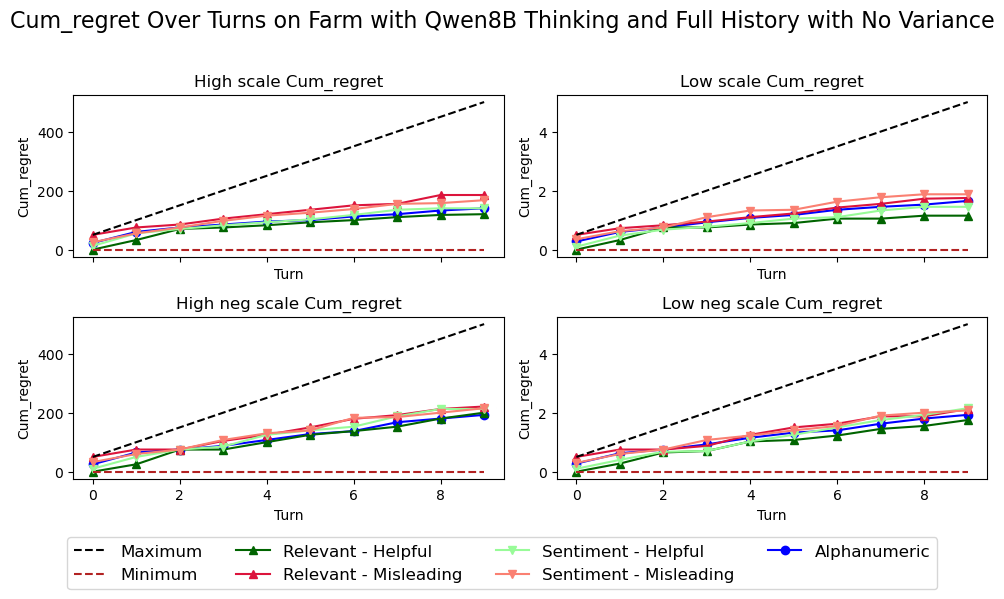

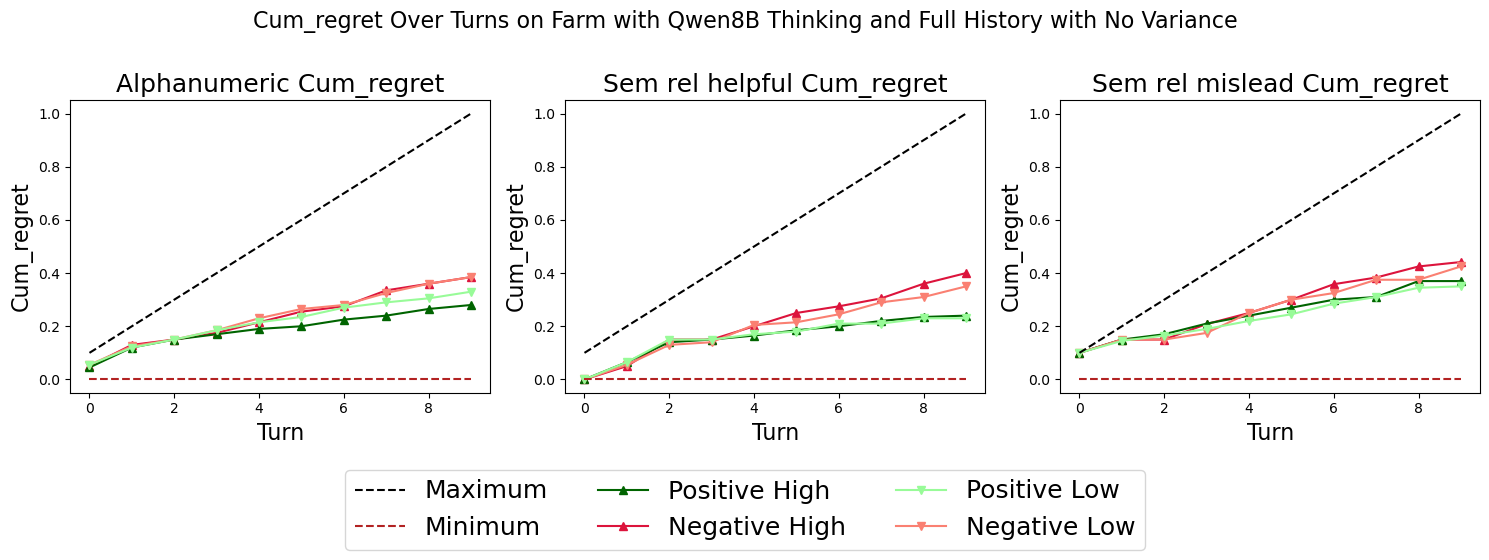

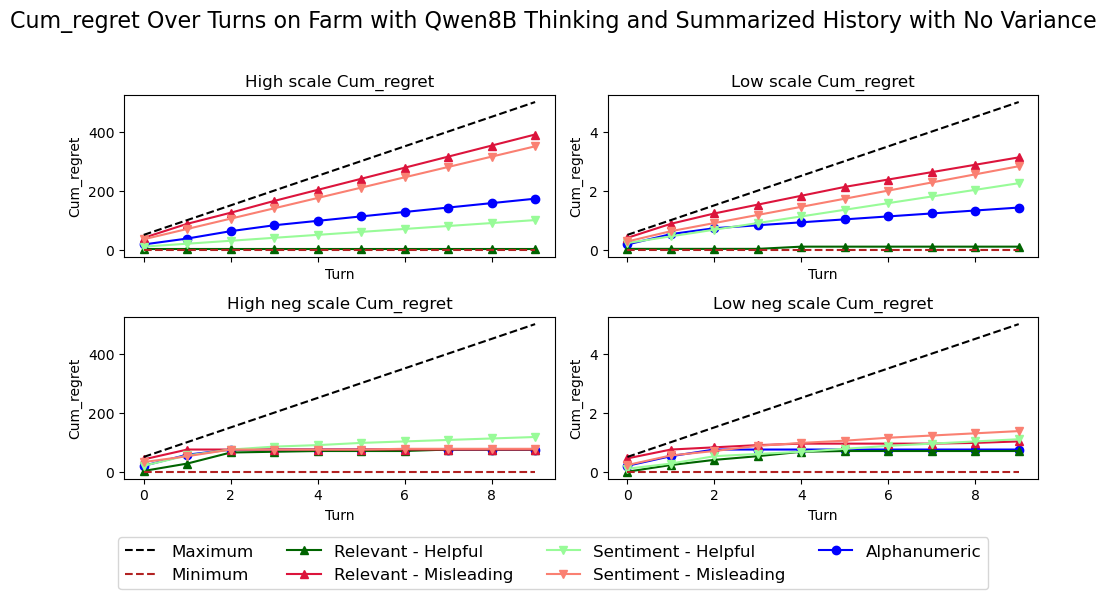

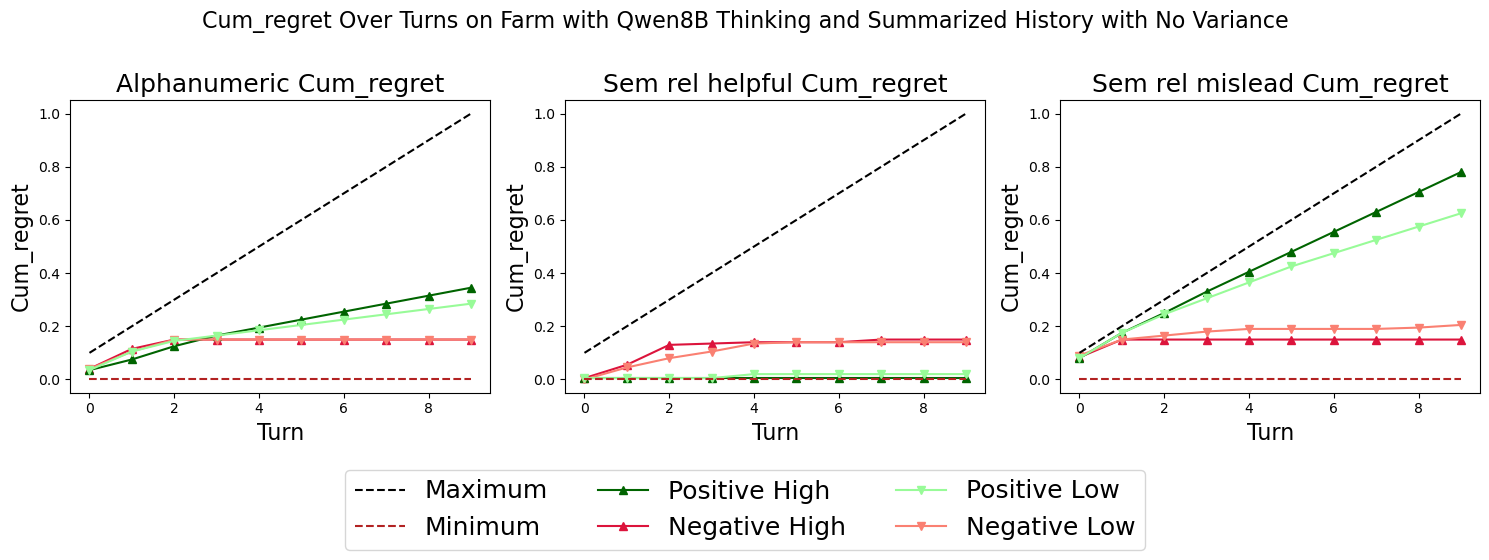

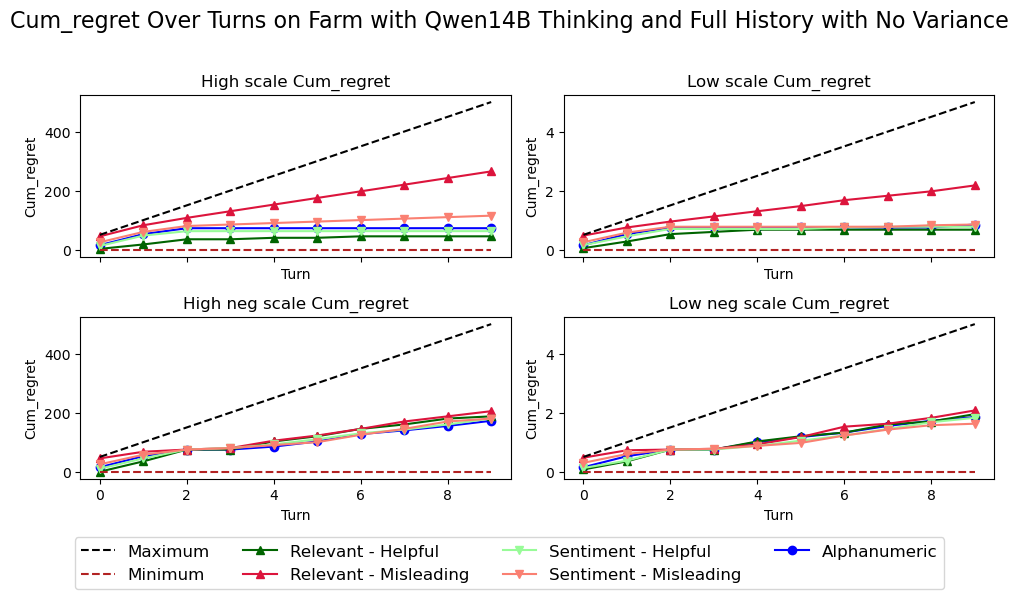

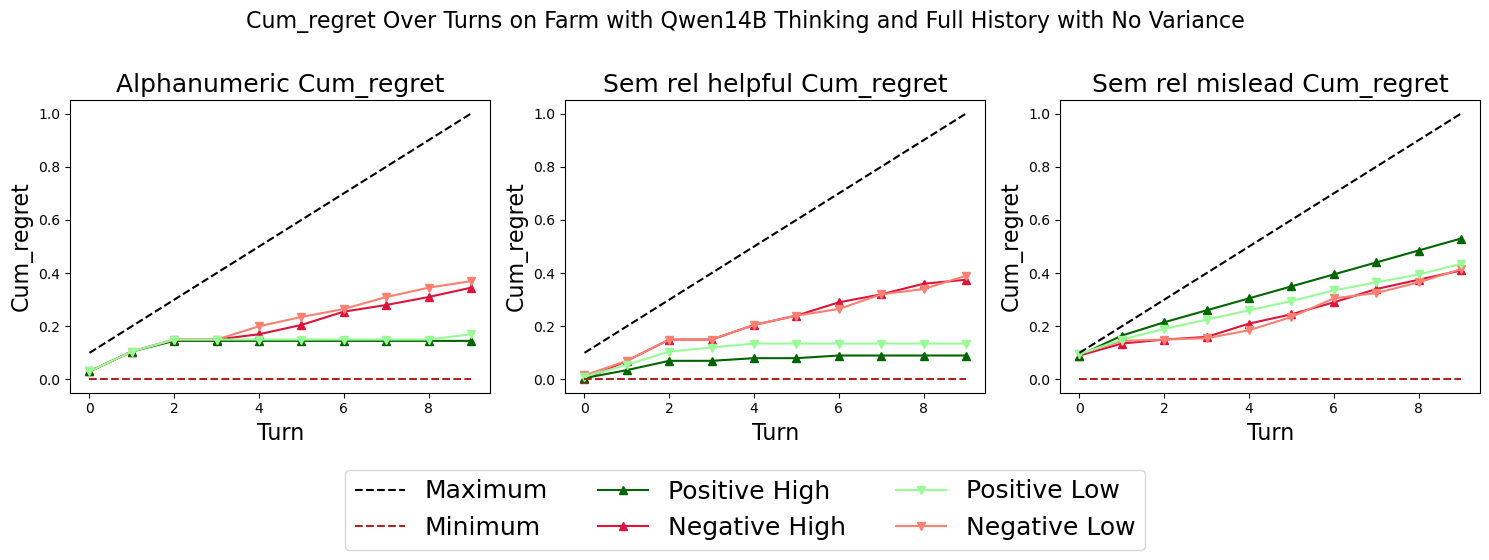

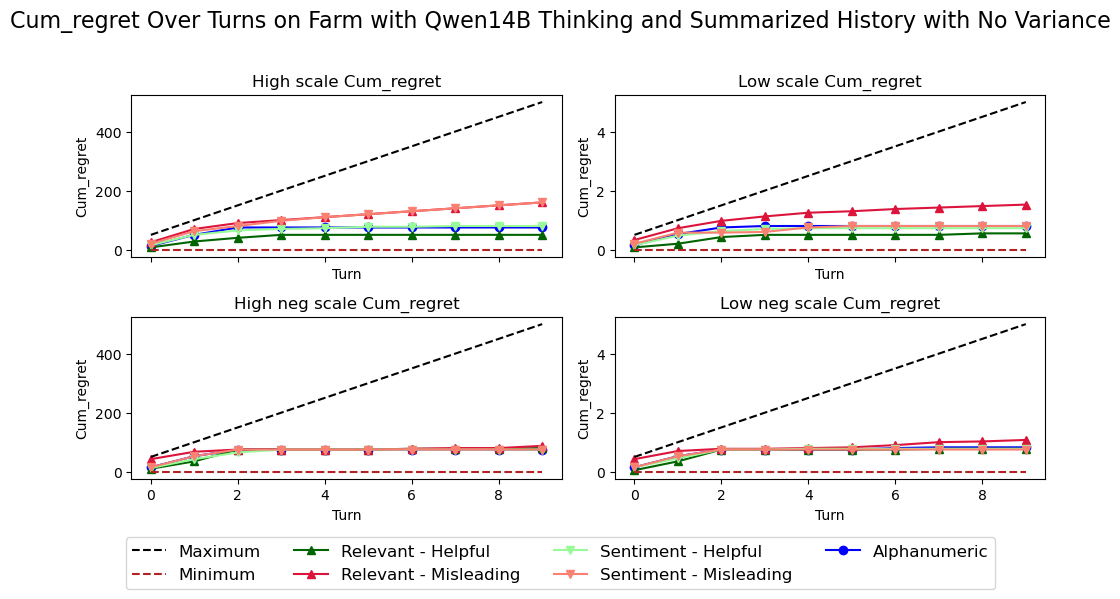

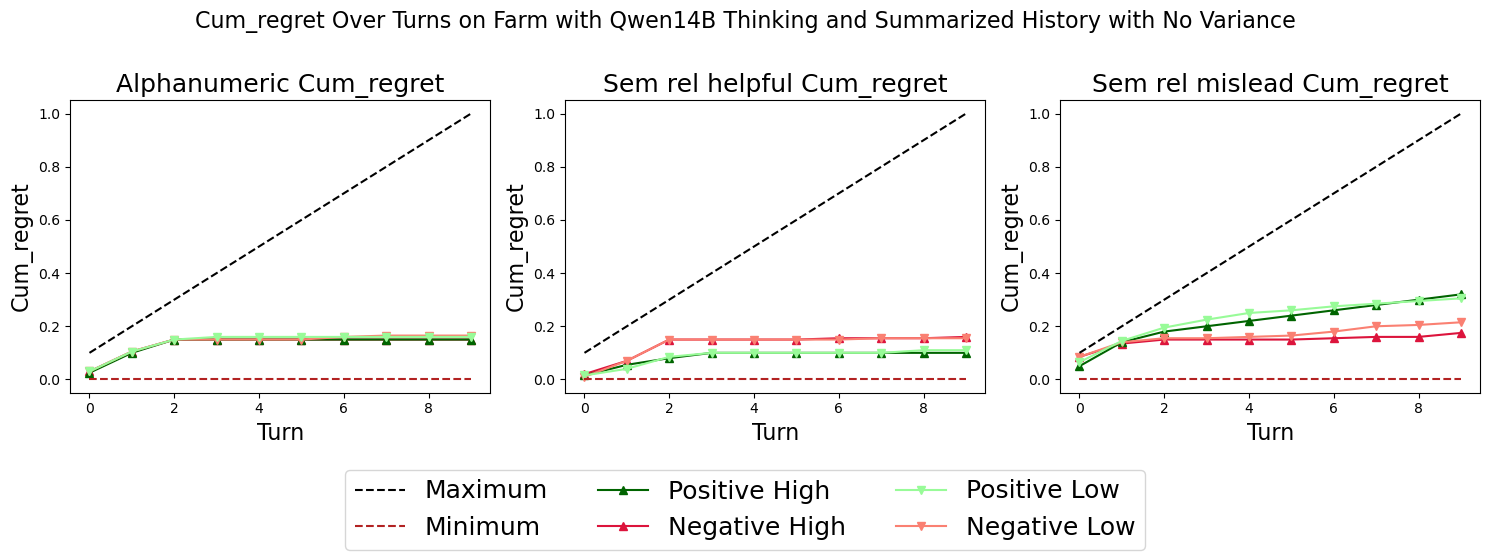

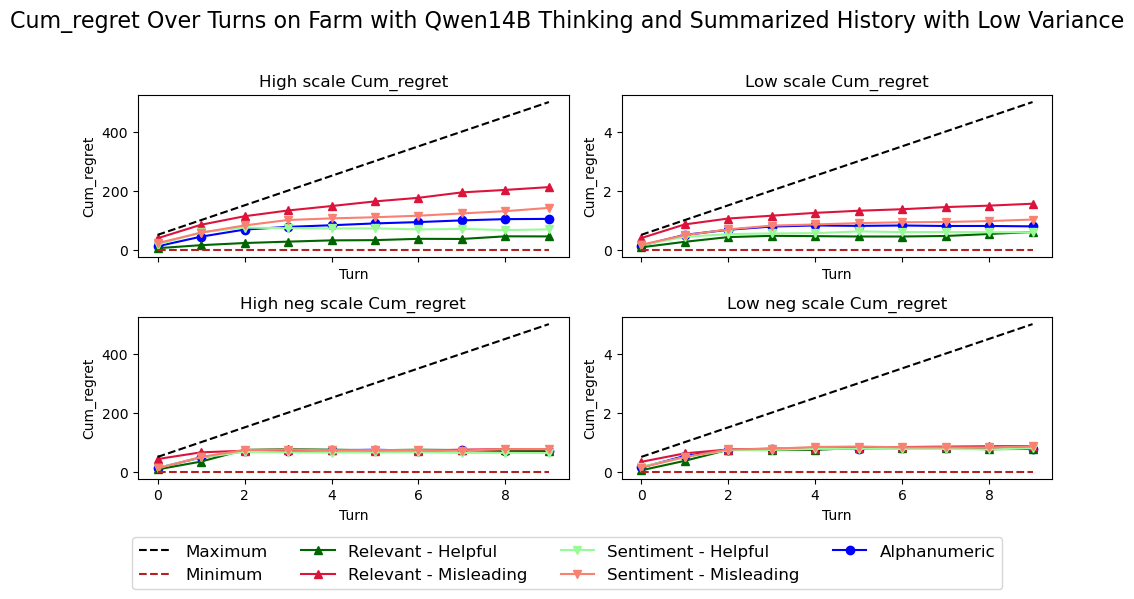

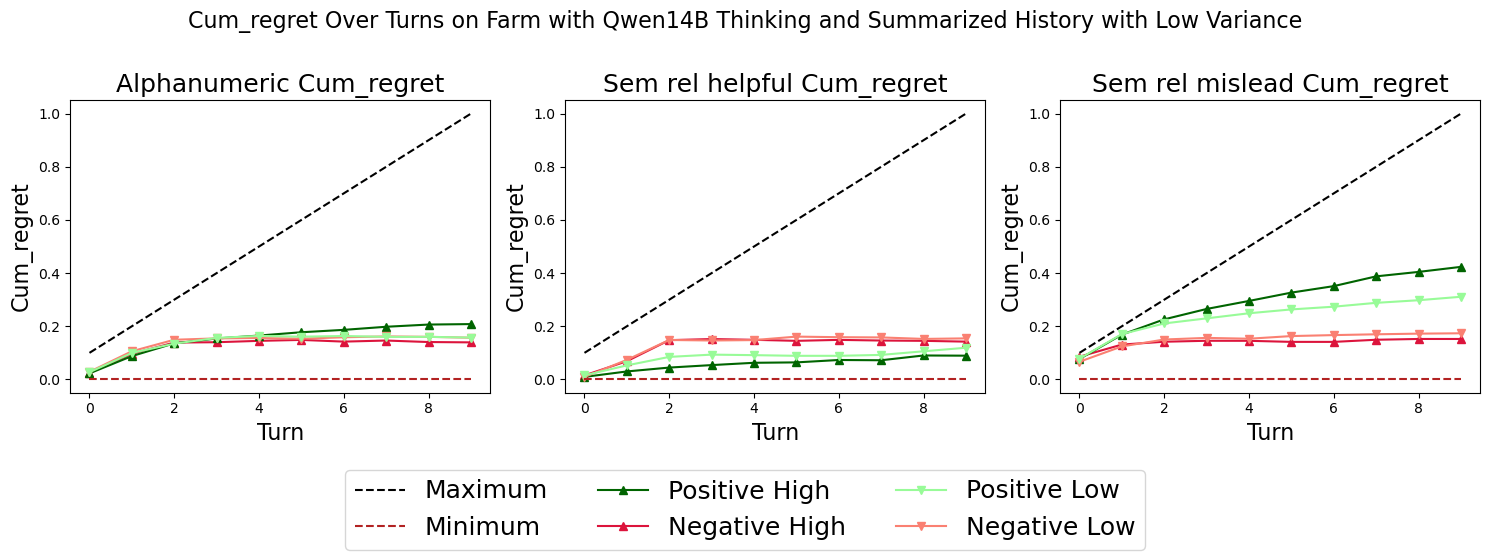

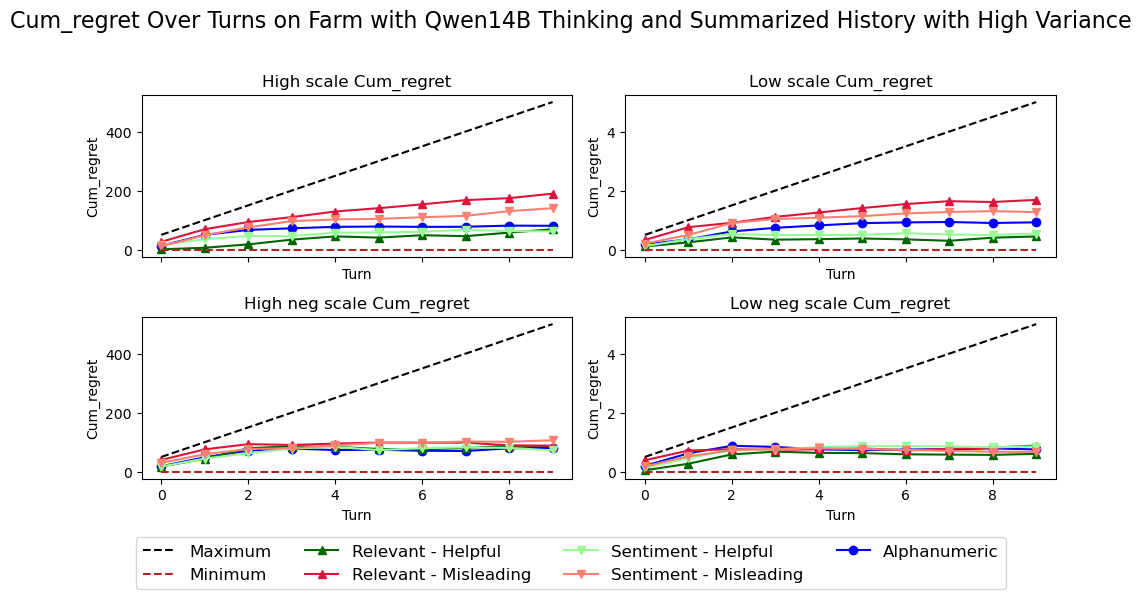

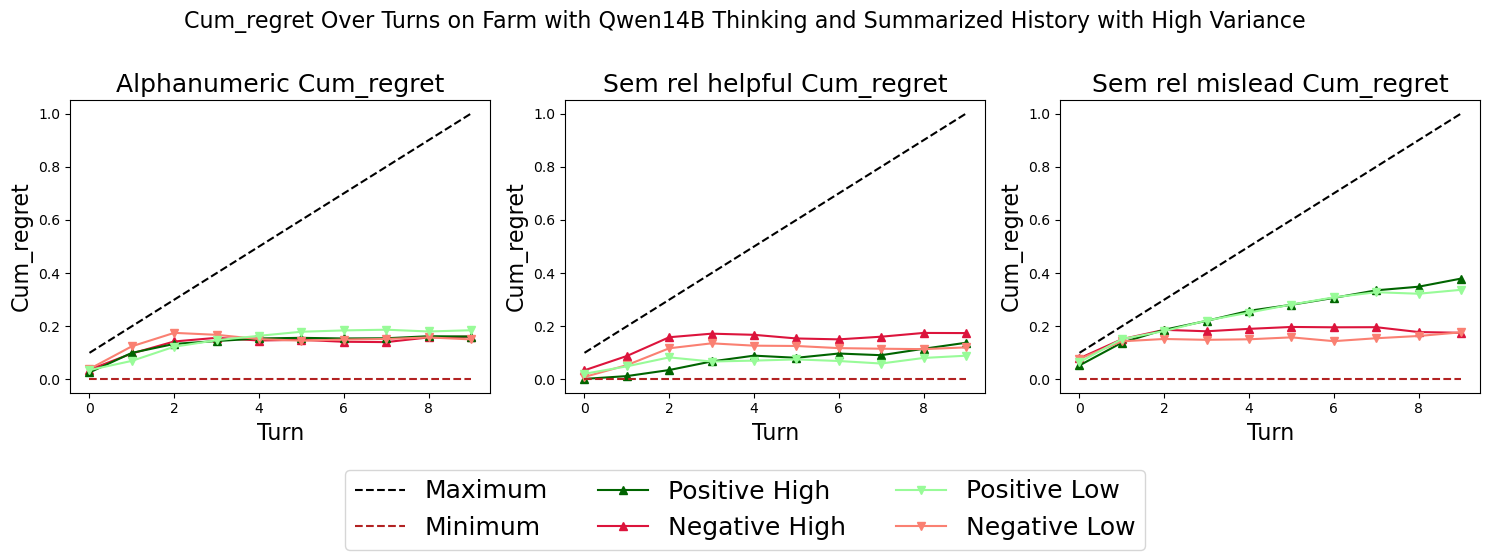

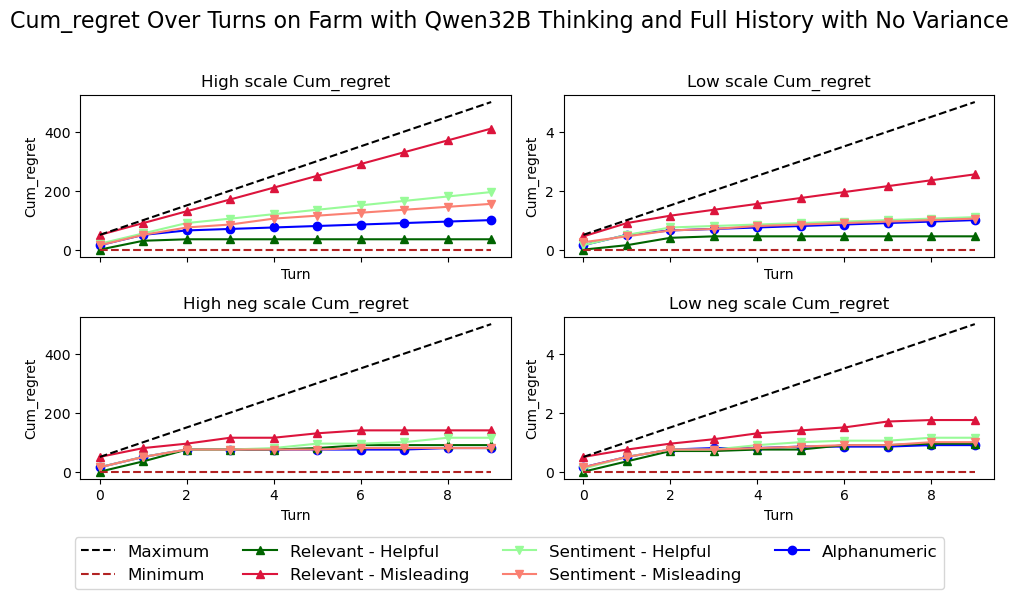

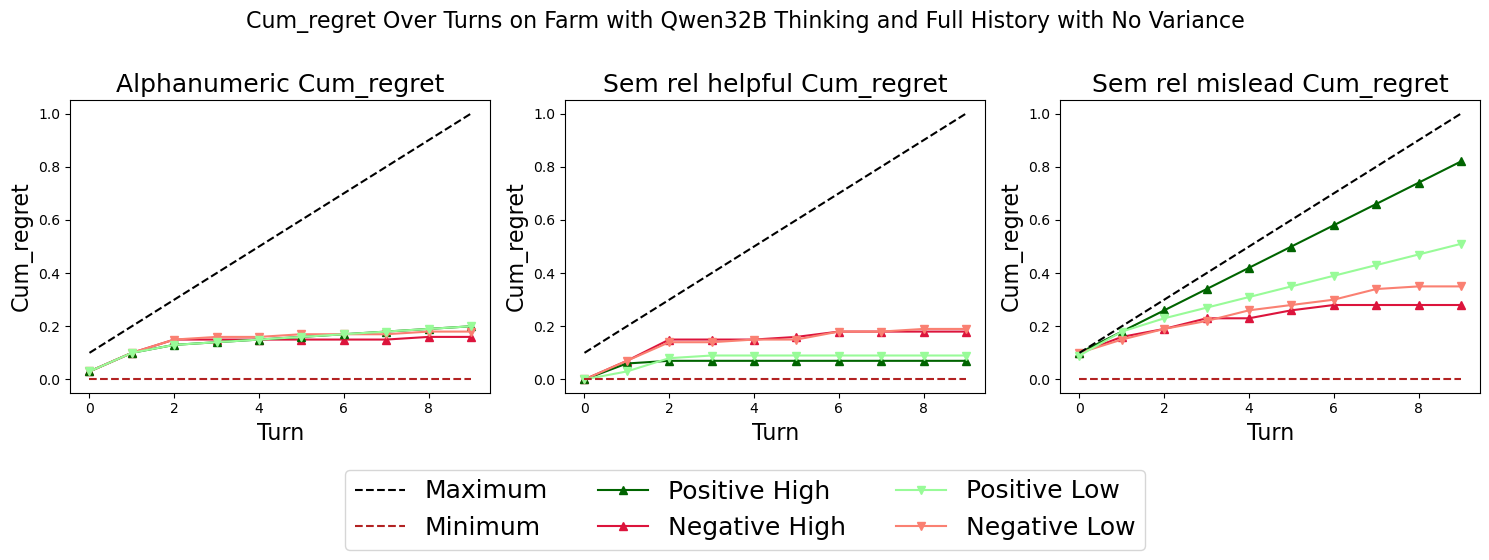

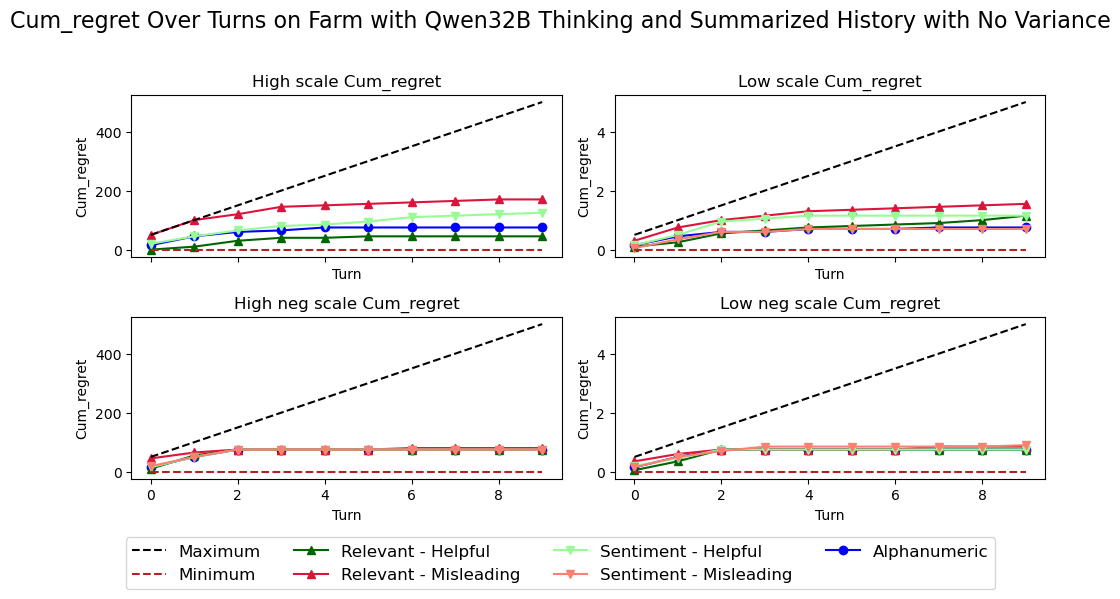

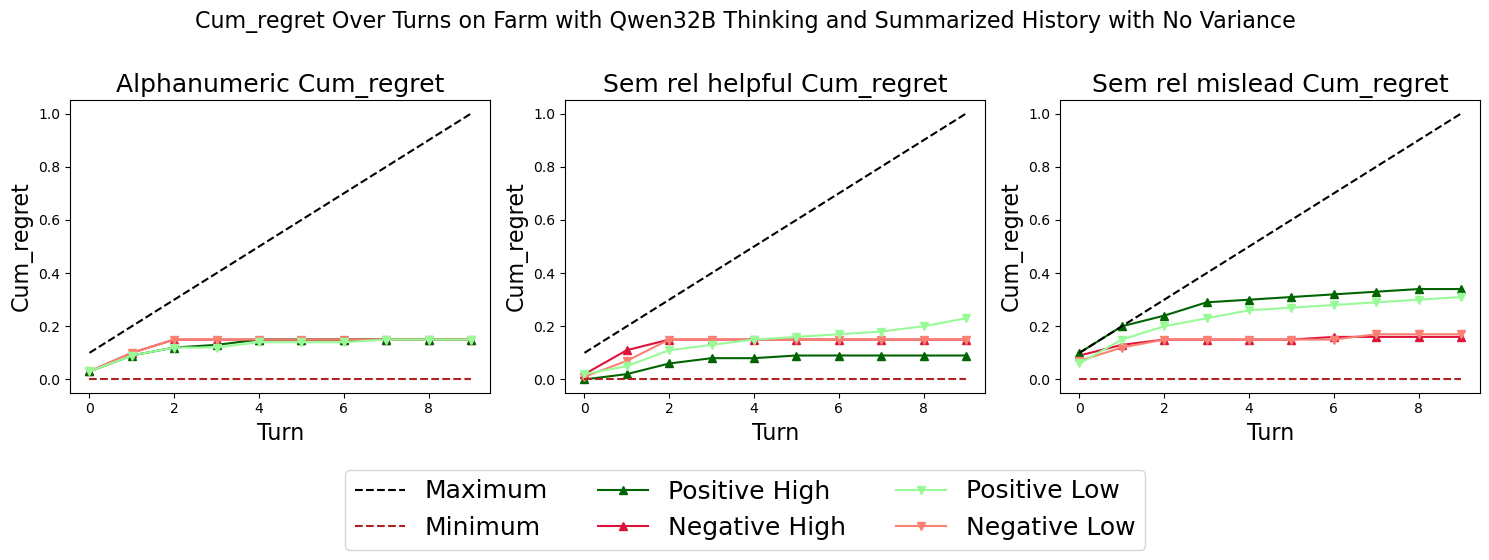

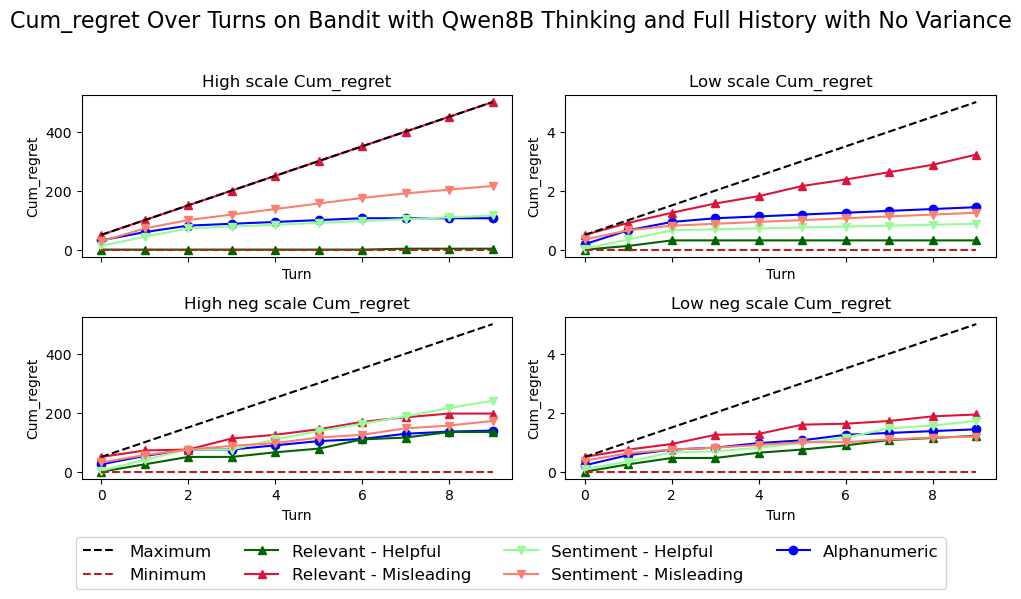

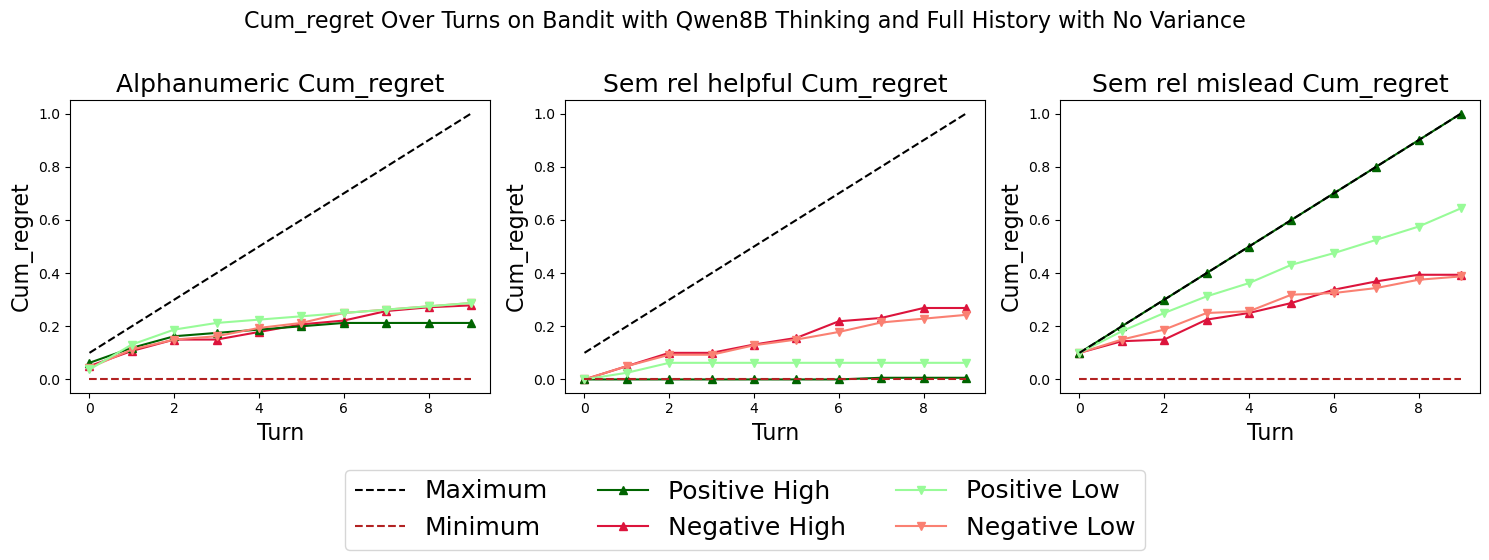

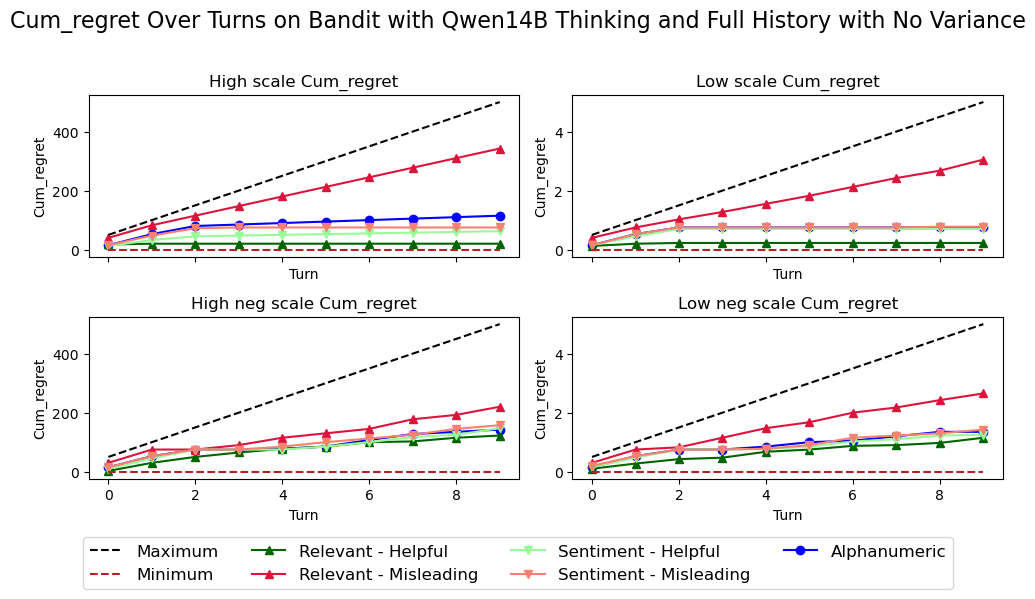

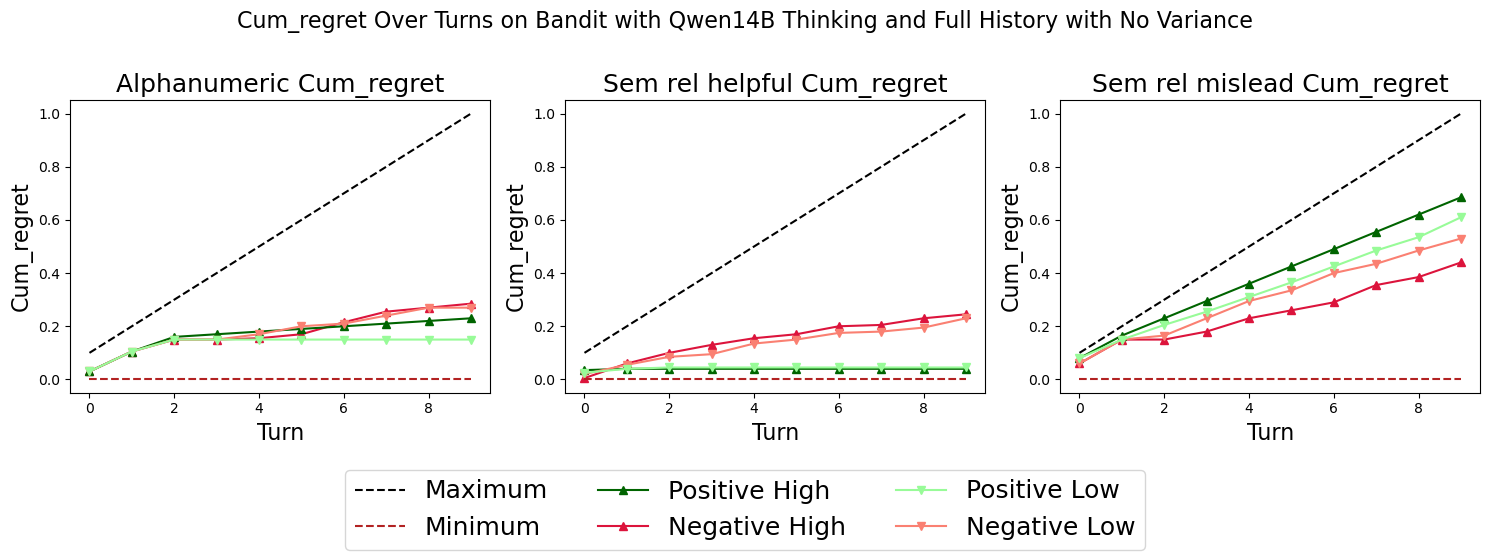

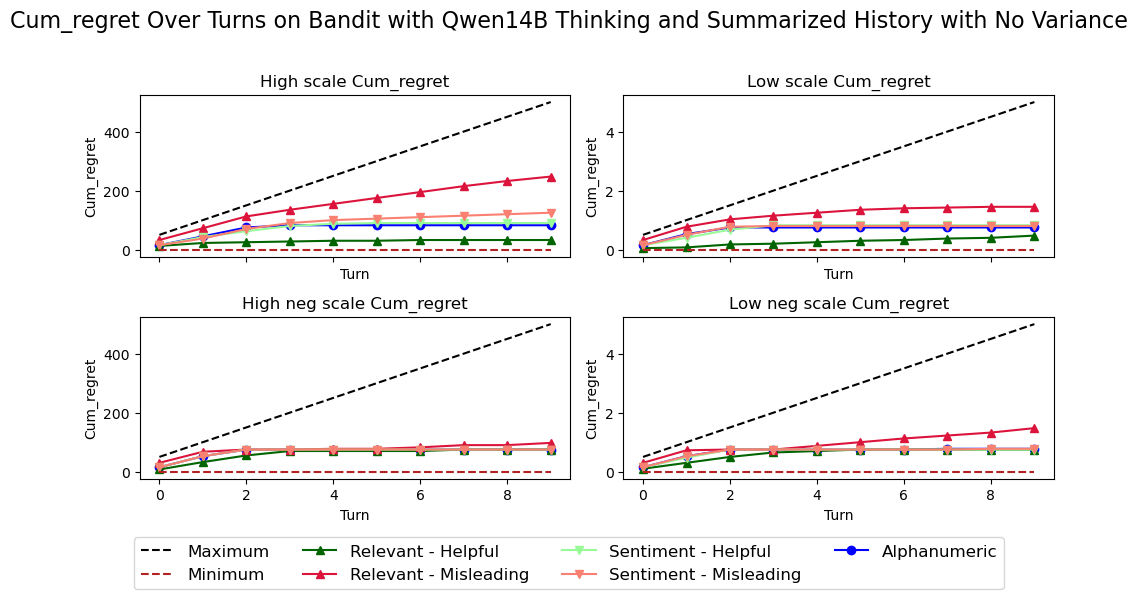

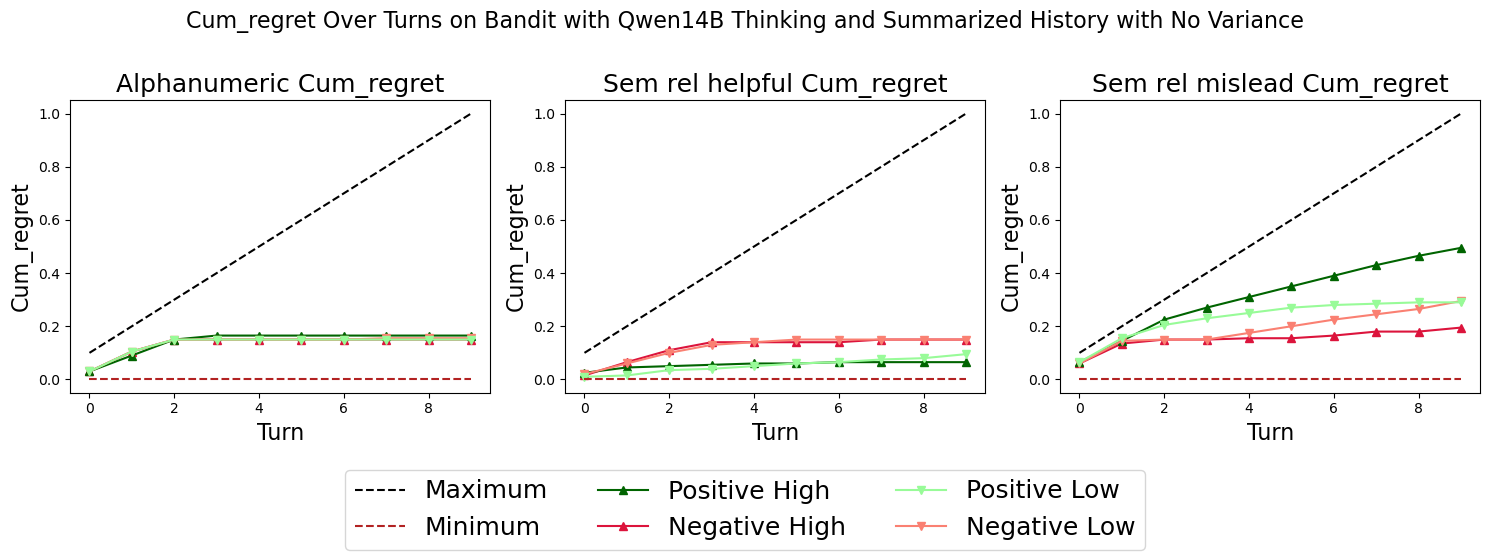

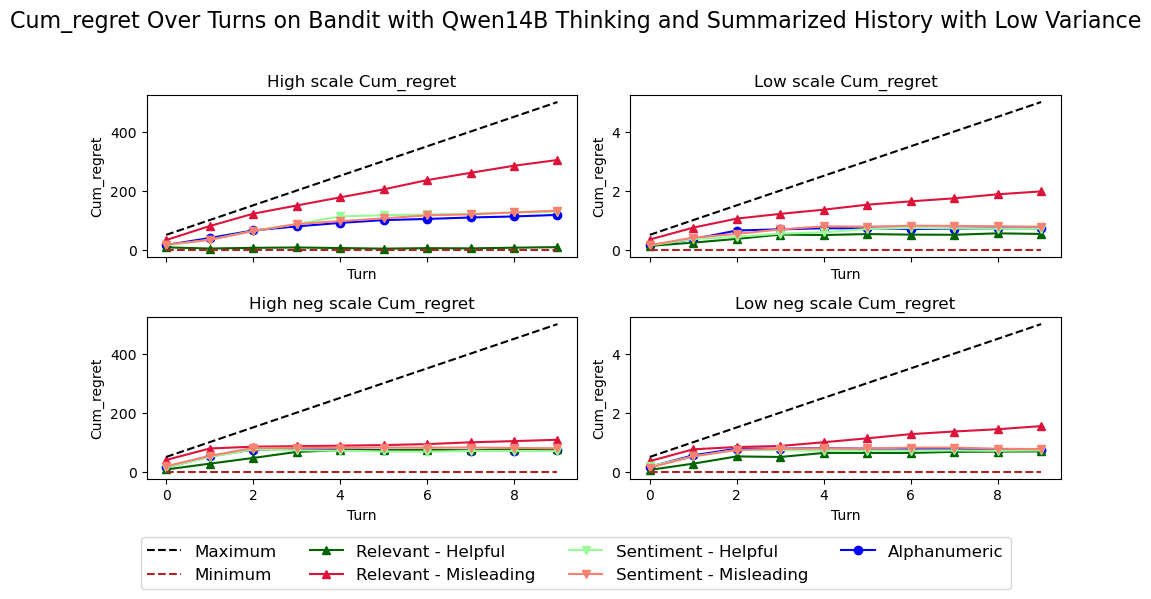

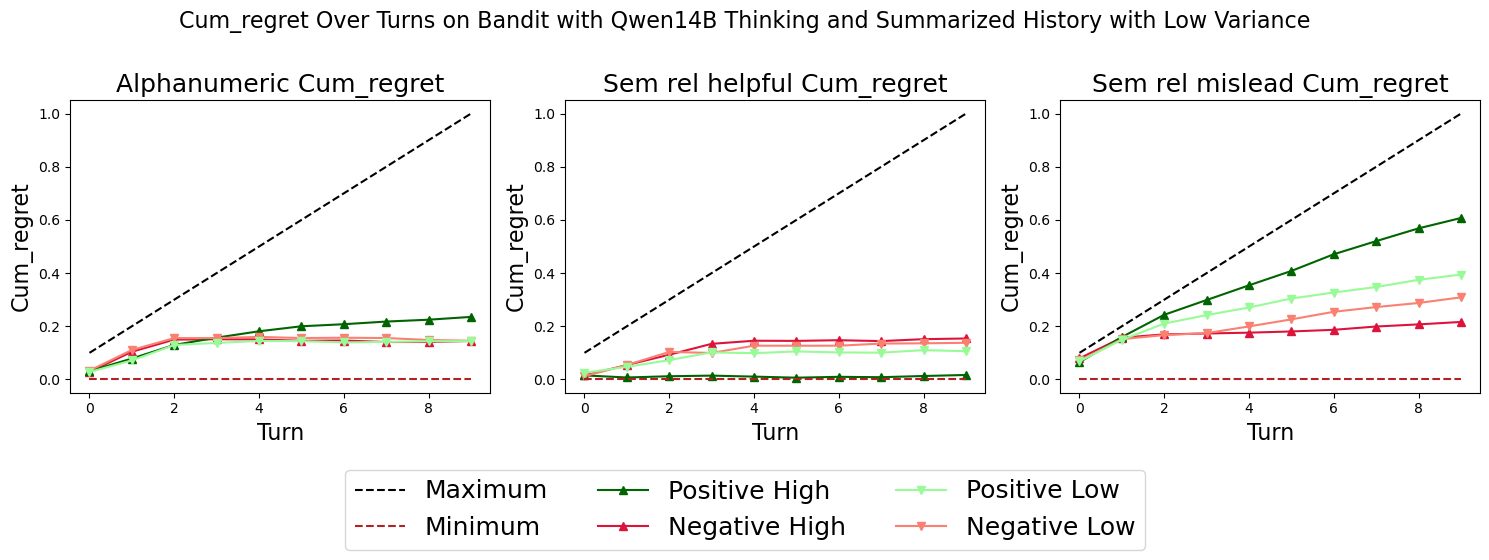

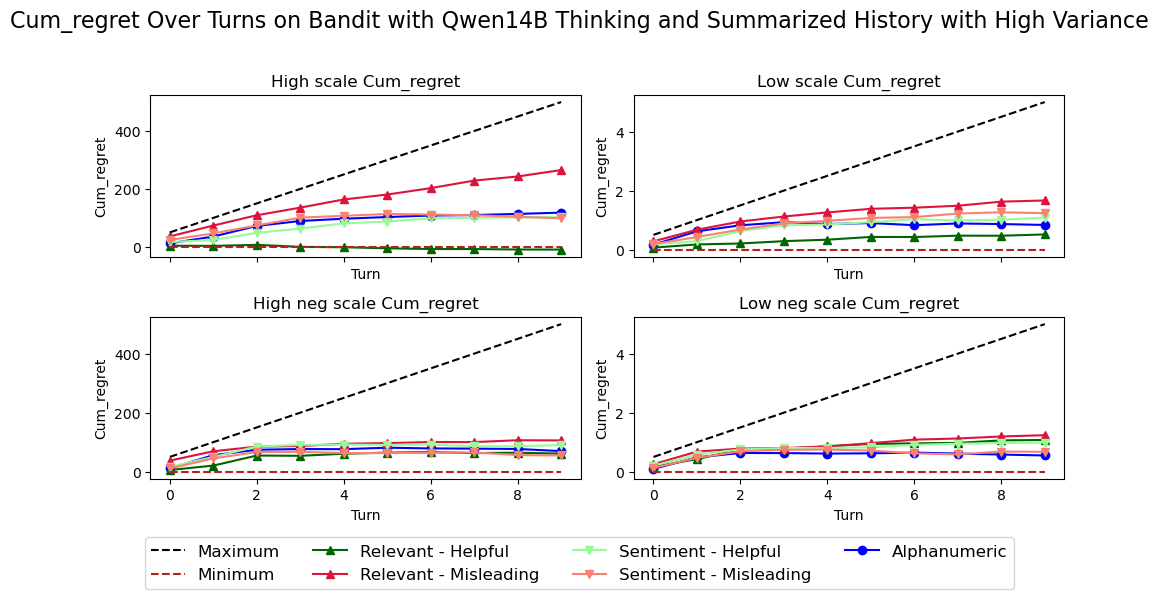

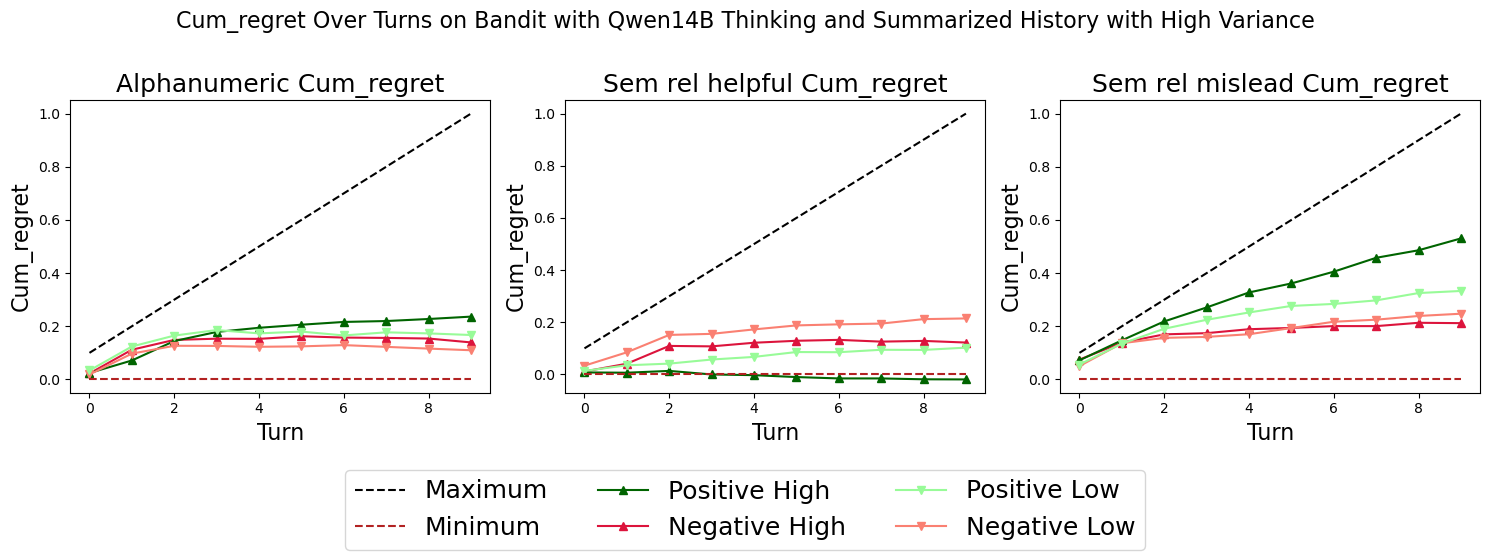

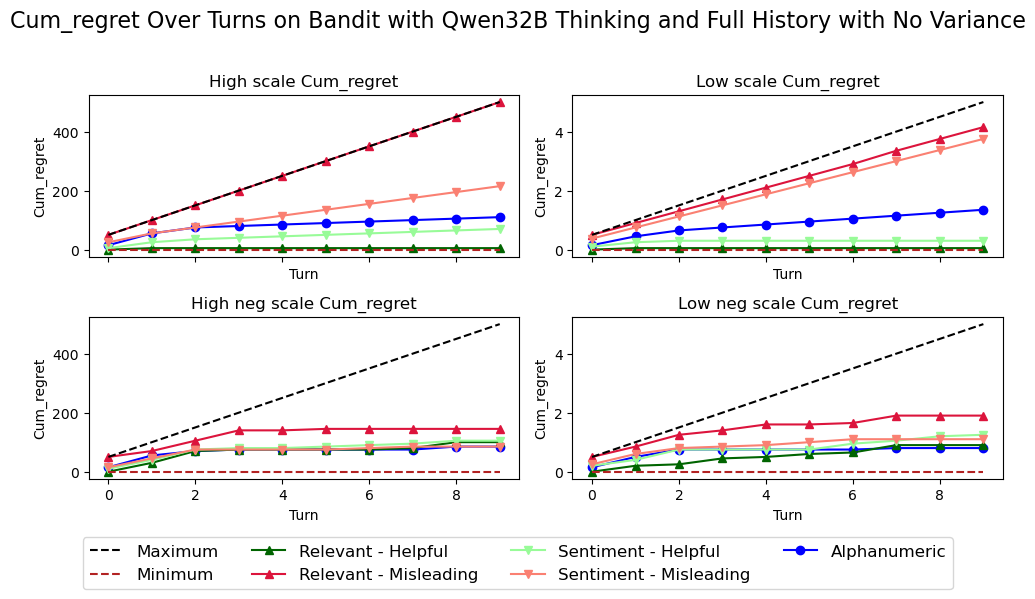

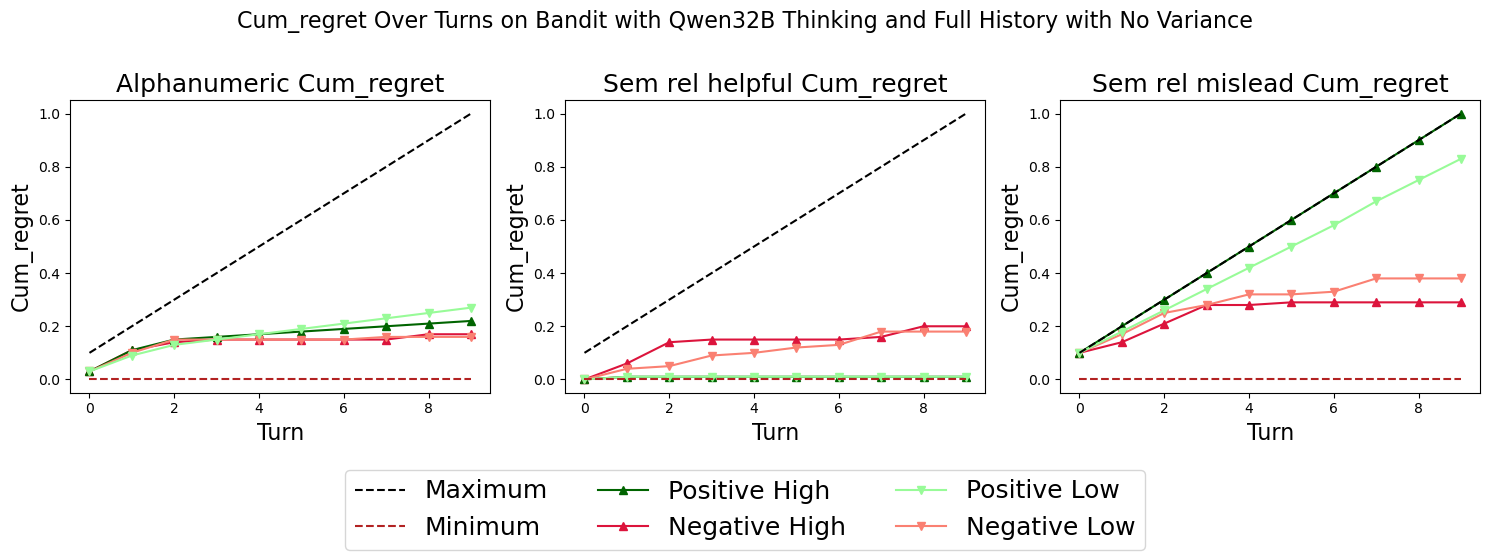

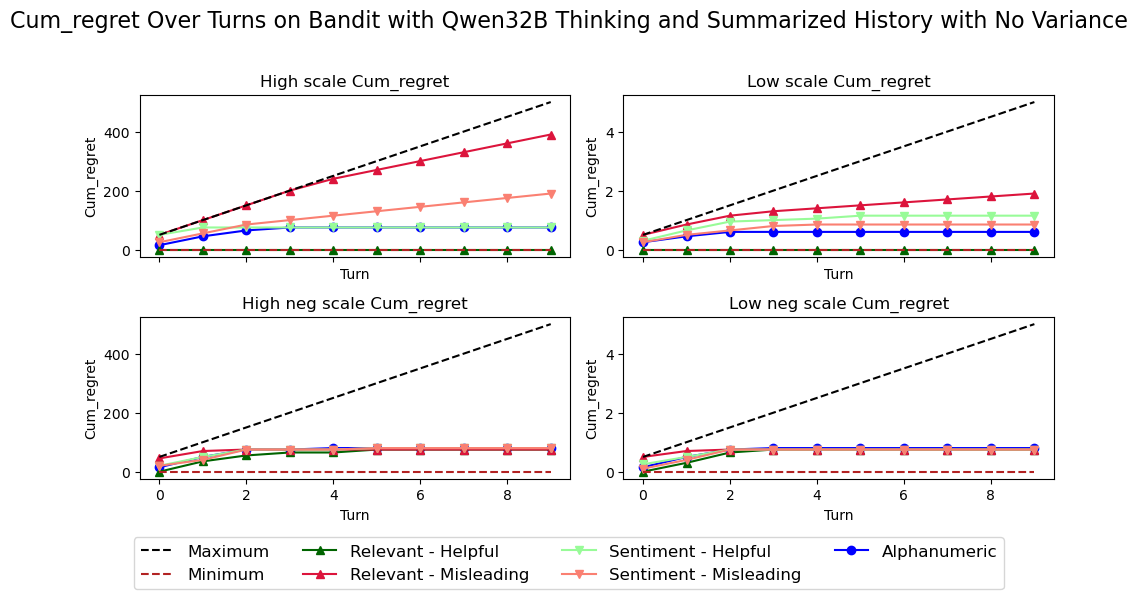

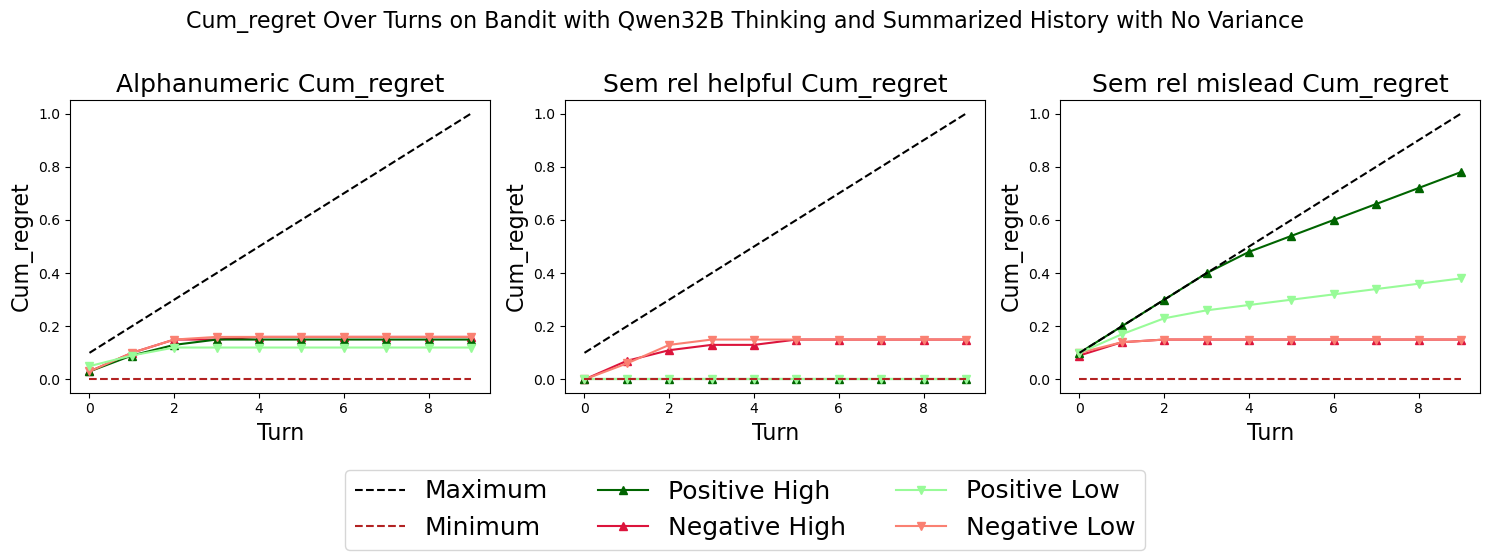

In [9]:
## First, we load in the merged dataframe
eval_path = 'experiments/merged_eval_results.csv'
results_df = load_csv(eval_path)

subplot_label = 'scale'
legend_label = 'nomenclature'

# metrics = ['cum_regret', 'sem_optimal_actions', 'reward_optimal_actions']
metrics = ['cum_regret']

for domain in results_df['Domain'].unique():
    for model in results_df['Model'].unique():
        for hist in results_df['History'].unique():
            for variance in results_df['Variance'].unique():
                subset = results_df[(results_df['Model'] == model) & (results_df['History'] == hist) & (results_df['Domain'] == domain) & (results_df['Variance'] == variance)]
                if subset.empty:
                    continue  # Skip if subset is empty
                for metric_key in metrics:
                    save_path_detail = f"/{model}/{hist}/{domain}/{variance}"
                    title = f"{metric_key.capitalize()} Over Turns on {domain} with {model} Thinking and {hist} History with {variance} Variance"
                    plot_regret_with_magnitude_subplots(subset, metric_key, subplot_label, legend_label, title, include_std=False, save_path_detail=save_path_detail)
                    plot_scaled_regret_with_name_subplots(subset, metric_key, legend_label, subplot_label, title, include_std=False, save_path_detail=save_path_detail)

## Dec 1 Plotting

In [10]:
eval_path = 'experiments/20251129_farm_qwen3/model_name_Qwen3-4B_time_horizon_8/eval_results.csv'
results_df = load_csv(eval_path)
results_df_dict = process_csv_data(results_df)

legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

for metric_key, metric_df in results_df_dict.items():
    if metric_key in ['percent_optimal']:
        continue
    title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 4B Thinking"
    plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)
    
# Potential failure modes: keywords cannot be subsets of each other

Loaded CSV file: experiments/20251129_farm_qwen3/model_name_Qwen3-4B_time_horizon_8/eval_results.csv


NameError: name 'percent_optimal_cols' is not defined

Loaded CSV file: experiments/20251129_farm_qwen3/model_name_Qwen3-8B_time_horizon_8/eval_results.csv


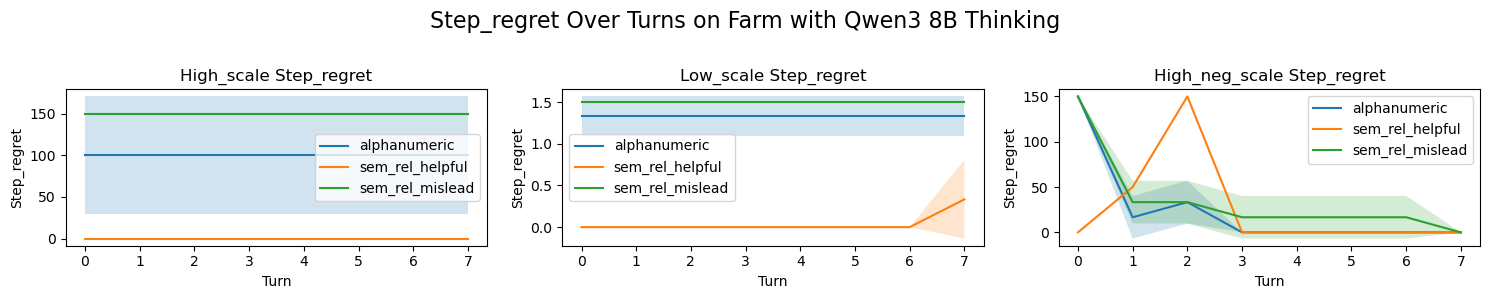

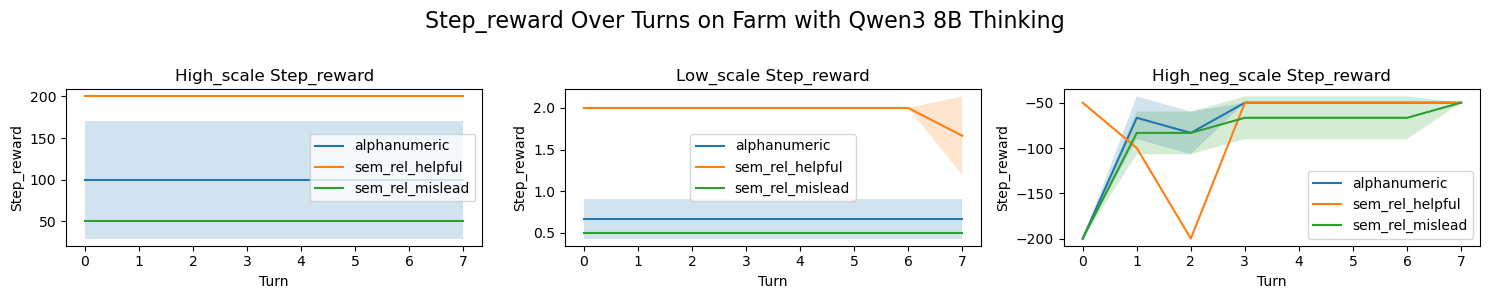

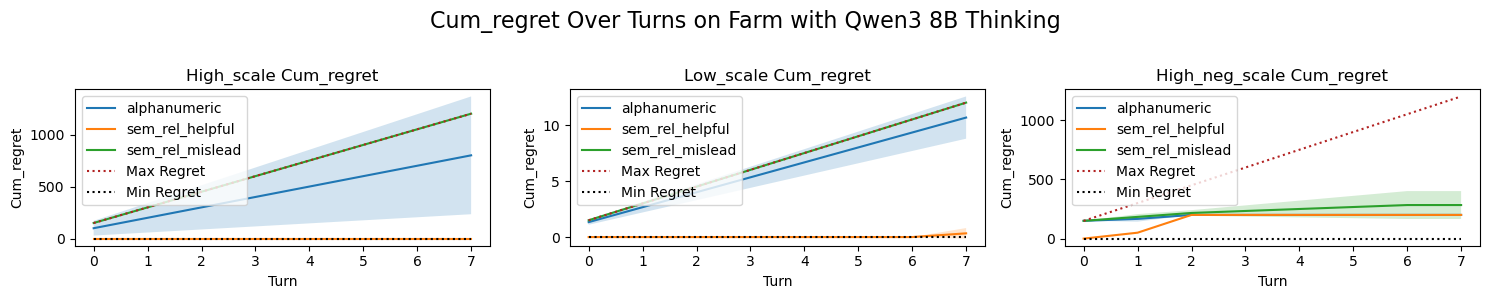

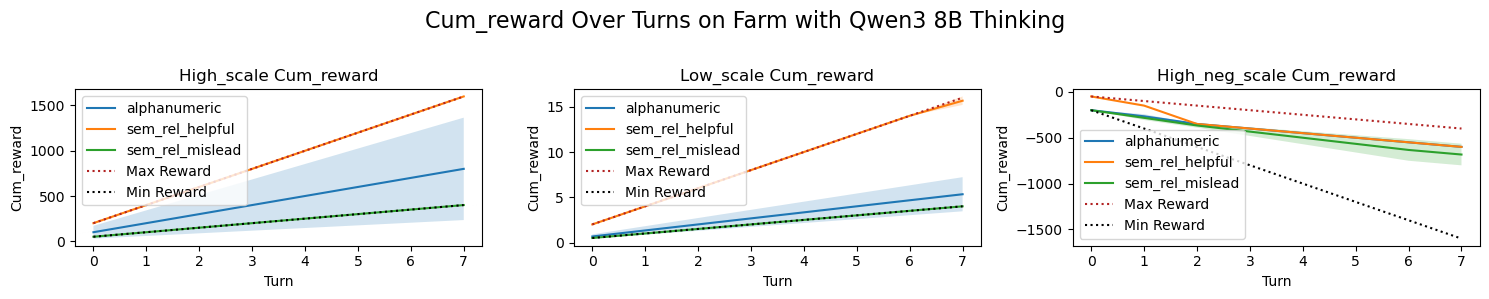

In [ ]:
eval_path = 'experiments/20251129_farm_qwen3/model_name_Qwen3-8B_time_horizon_8/eval_results.csv'
results_df = load_csv(eval_path)
results_df_dict = process_csv_data(results_df)

legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

for metric_key, metric_df in results_df_dict.items():
    if metric_key in ['percent_optimal']:
        continue
    title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 8B Thinking"
    plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)

Loaded CSV file: experiments/20251129_farm_qwen3/model_name_Qwen3-14B_time_horizon_8/eval_results.csv


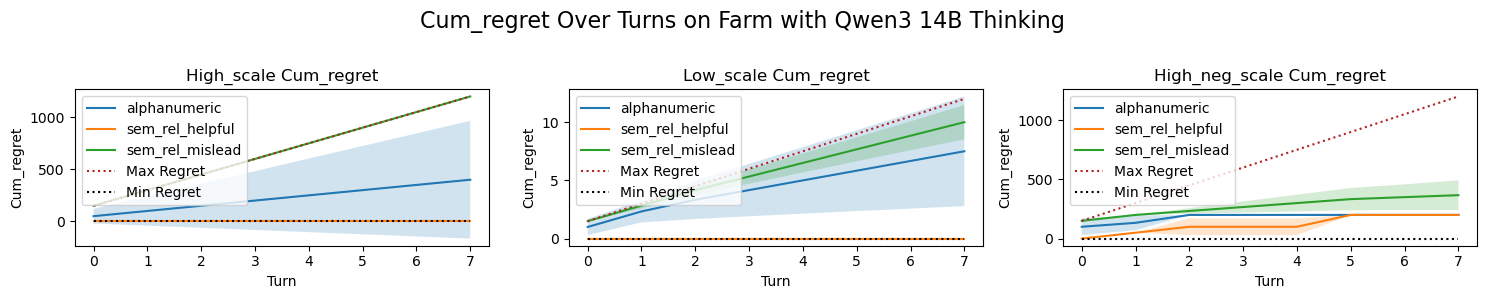

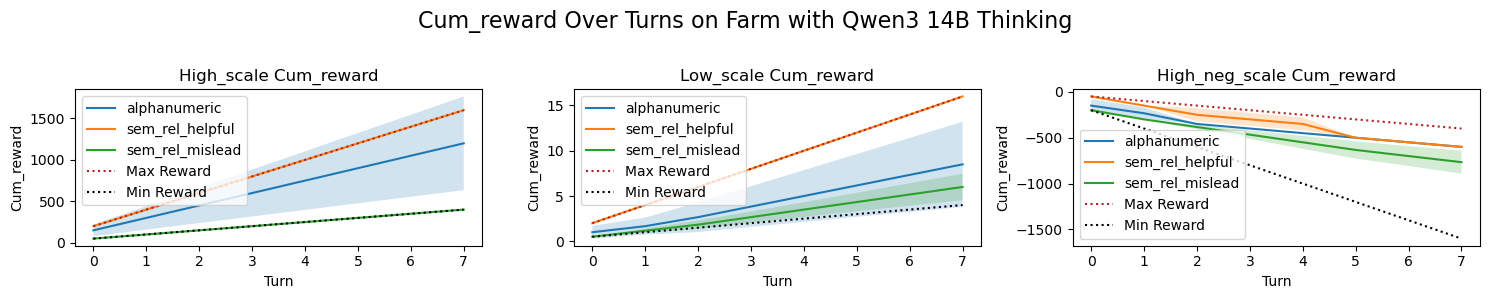

In [ ]:
eval_path = 'experiments/20251129_farm_qwen3/model_name_Qwen3-14B_time_horizon_8/eval_results.csv'
results_df = load_csv(eval_path)
results_df_dict = process_csv_data(results_df)

legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

for metric_key, metric_df in results_df_dict.items():
    if metric_key in ['percent_optimal', 'step_regret', 'step_reward']:
        continue
    title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 14B Thinking"
    plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)

## Comparing History Passing

What am I trying to show here? Do the different history prompting styles have an impact on model performance? So we'll just plot all of them and compare side by side I guess?

In [ ]:
eval_paths = {
    '8B_actionhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv',
    '8B_fullhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv',
    '8B_summhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv',
    '14B_actionhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv',
    '14B_fullhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv',
    '14B_summhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv',
}

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv


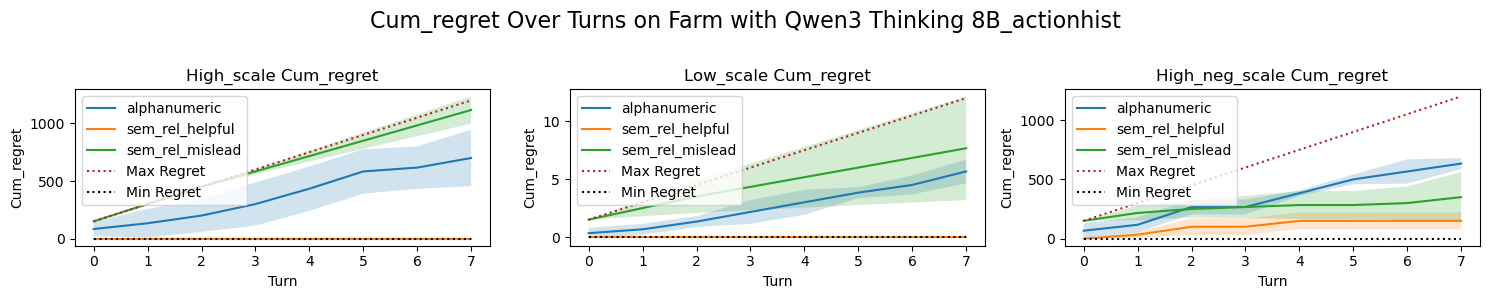

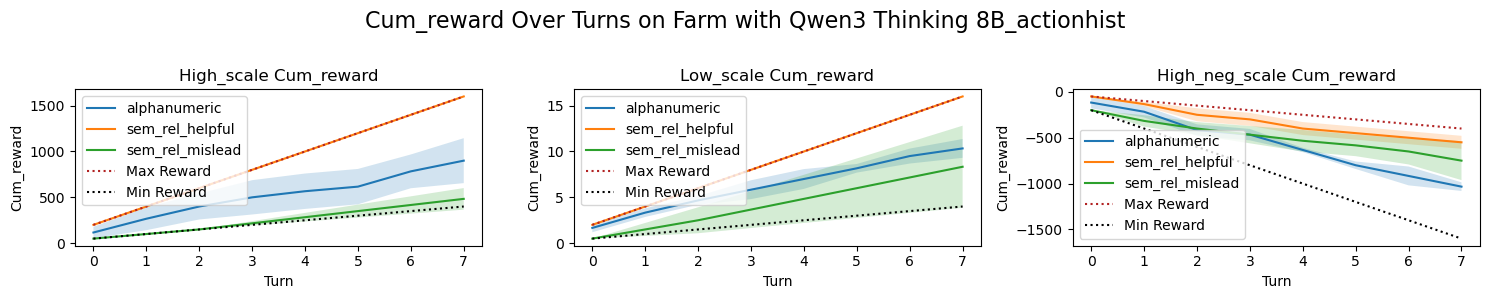

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv


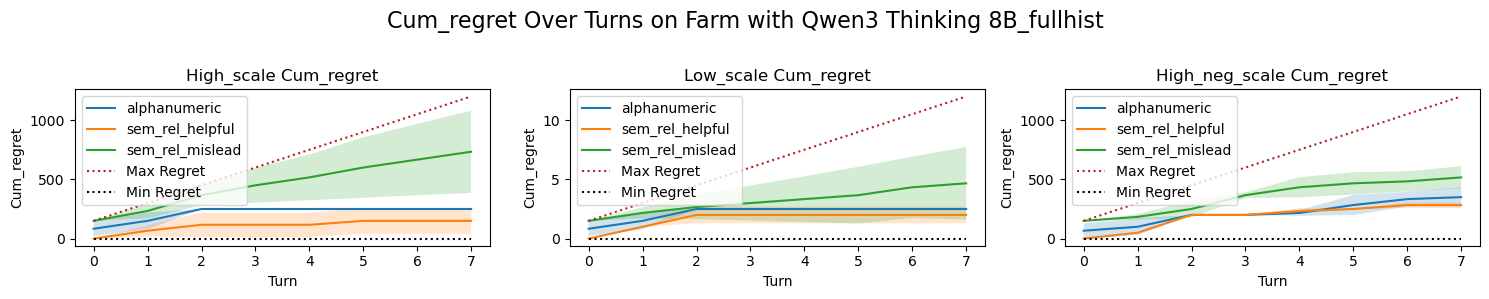

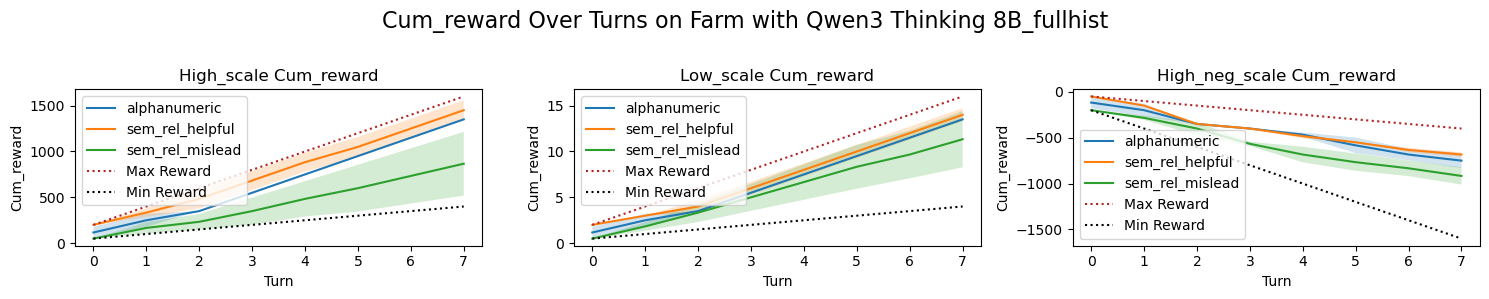

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv


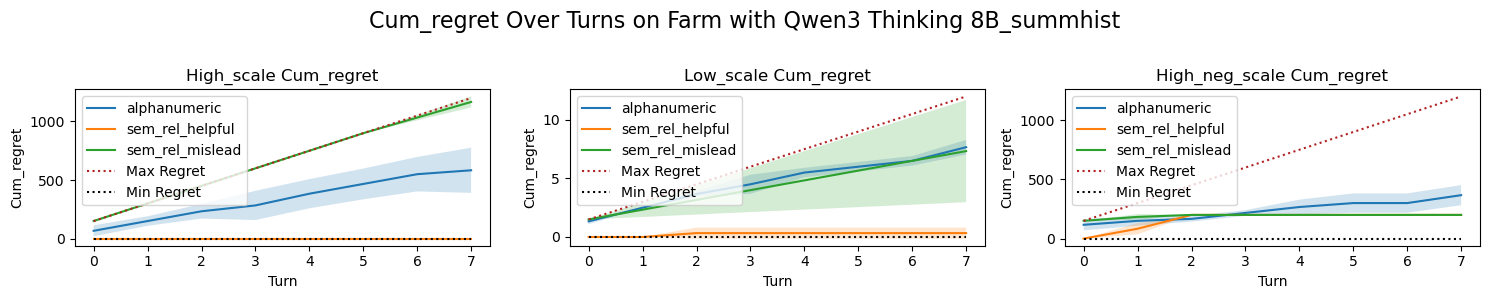

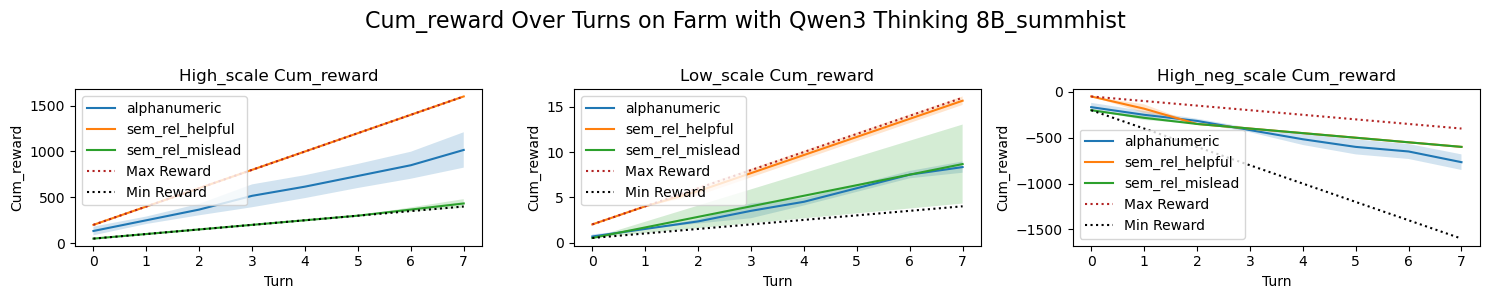

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv


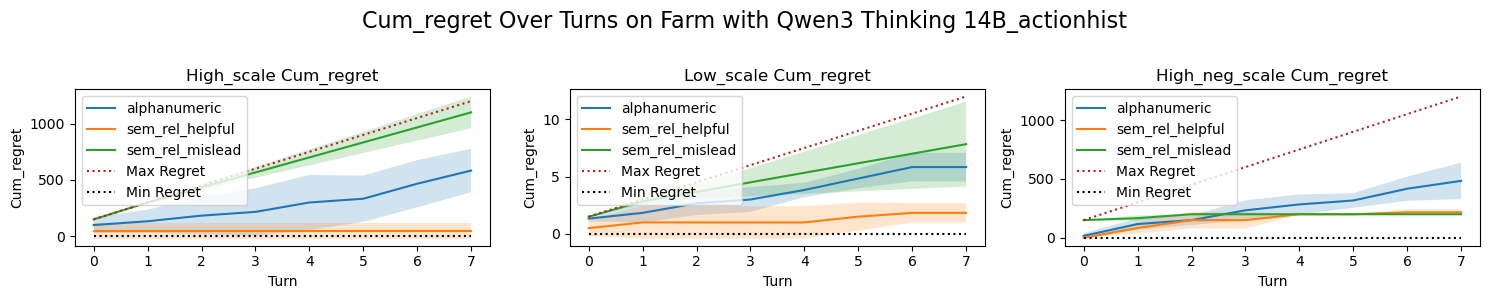

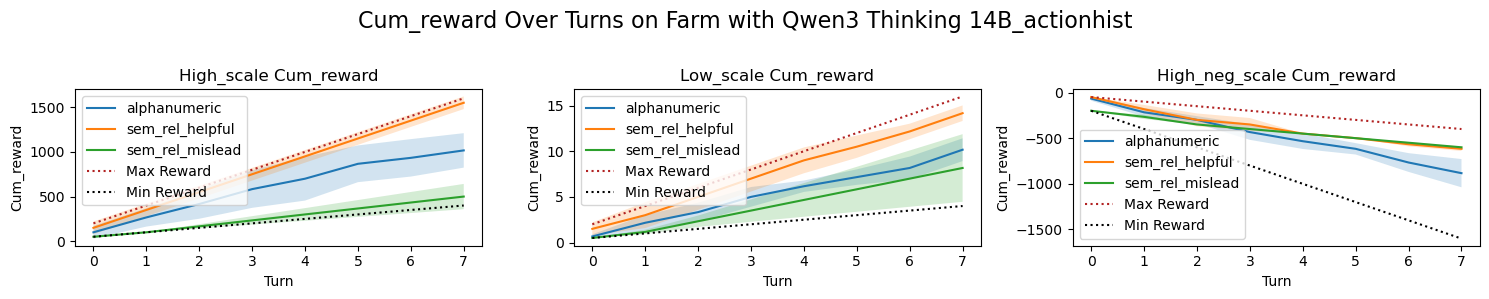

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv


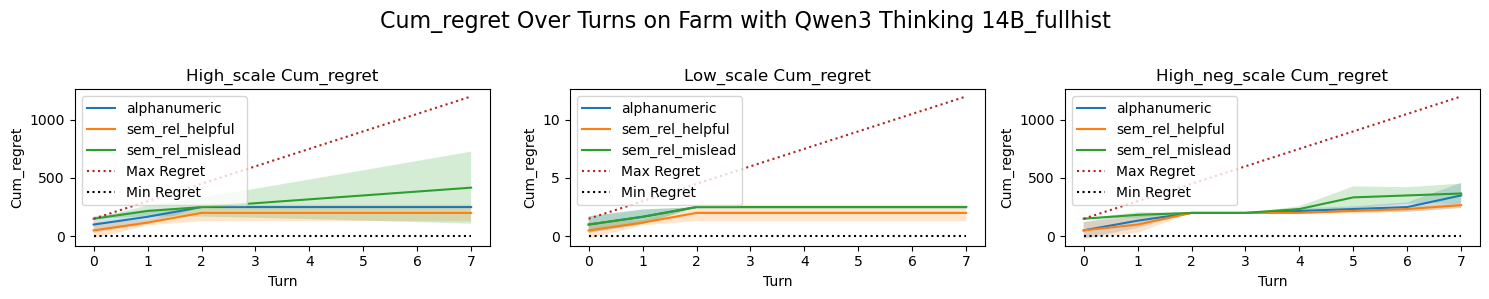

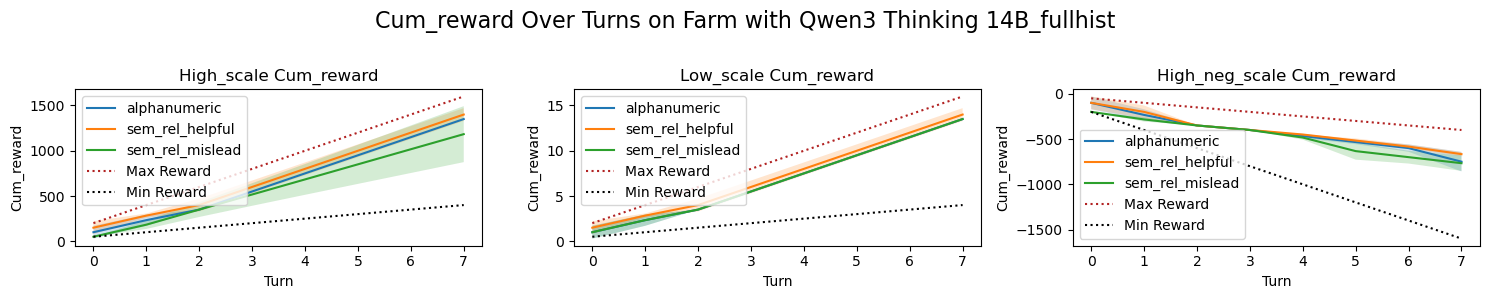

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv


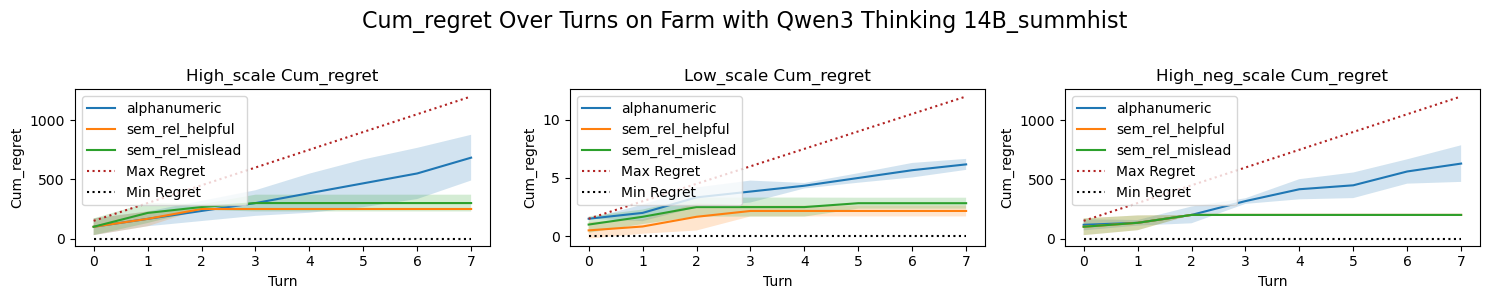

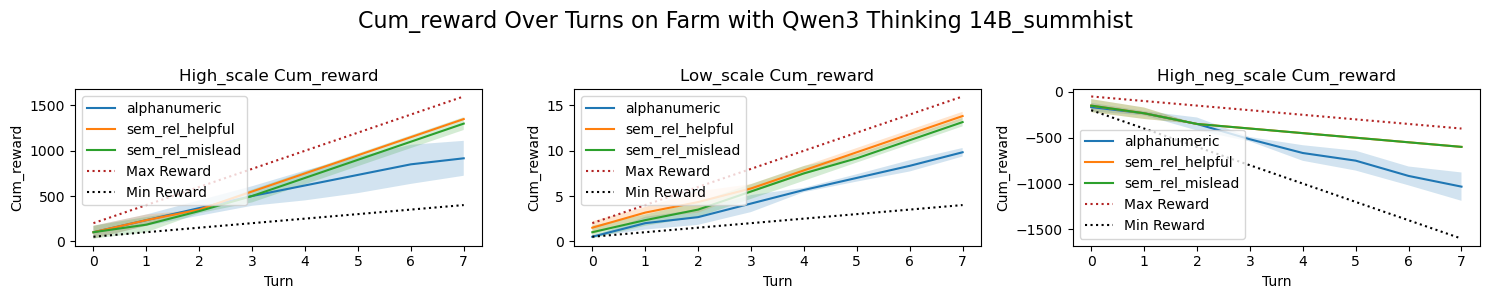

In [ ]:
for eval_path_name, eval_path in eval_paths.items():
    results_df = load_csv(eval_path)
    results_df_dict = process_csv_data(results_df)

    legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
    subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

    for metric_key, metric_df in results_df_dict.items():
        if metric_key in ['percent_optimal', 'step_regret', 'step_reward']:
            continue
        title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 Thinking {eval_path_name}"
        plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)

## Dec 10 - Scale vs Arm Names Total Regret Heatmaps

In [ ]:
## 